In [36]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [37]:
database=['llnl.dat'];

In [38]:
% variables

% amounts
XP=0.020; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [39]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [40]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [41]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [42]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [43]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [44]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [45]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  









Simulation 1. Kinetic step 3.                                                  









Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  









Simulation 1. Kinetic step 6.                                                  









Simulation 1. Kinetic step 7.                                                  









Simulation 1. Kinetic step 7.                                                  









Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 9.                                                  









Simulation 1. Kinetic step 10.       

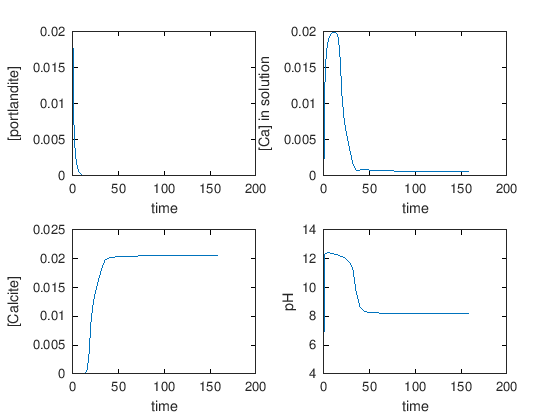

In [46]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [47]:
% data
%6 g cement small size

data=[...
0.00	6.2	-0.11521	NaN	0.46173	0.02
0.10	12.01	2.36746	2304	8.89050	0.09
2.00	12.37	0.87121	5030	12.36900	0.04
24.00	11.71	1.55604	1443	1.60505	0.14
48.00	10.37	0.61367	563.00	2.05273	0.41
72.00	8.24	0.70992	695.00	2.53700	1.06
96.00	8.12	0.84817	701.00	2.64850	1.11
144.00	8.07	0.74929	725.00	2.78225	1.01			
0.00	NaN	-0.0677	NaN	0.05332	0.00593
0.10	11.83	0.2917	3120.0	1.44430	0.07079
2.00	12.29	2.0213	4840	11.35500	0.05282
4.00	12.27	0.7799	4600.00	10.93675	0.05004
24.00	11.84	1.1524	1804	3.99875	0.11489
48.00	10.51	1.1541	538	1.69698	0.47893
72.00	8.23	1.19	598	2.22893	1.15714
96.00	8.08	1.19	608.00	2.25175	1.18536
171	8.02	0.905916667	673	2.390375	1.09857					
0.00	6.00	-0.0502	NaN	0.18667	-0.0011
0.10	12.13	0.6568	2949.0	7.45650	0.1055
2.00	12.37	0.2514	4470	9.36300	0.0490
4.00	12.37	0.4920	4330.00	9.26400	0.0474
24.00	11.84	1.8229	1239	2.19903	0.1815
48.00	10.07	0.5154	508	2.28738	0.5114
72.00	8.22	1.1780	658	2.54600	1.3182
96.00	8.14	0.9879	658	2.49013	1.2396
171.00	8.07	0.88	737.00	2.45545	1.1082
];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


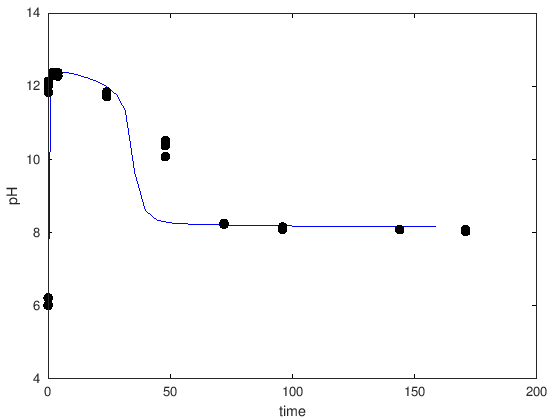

In [48]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

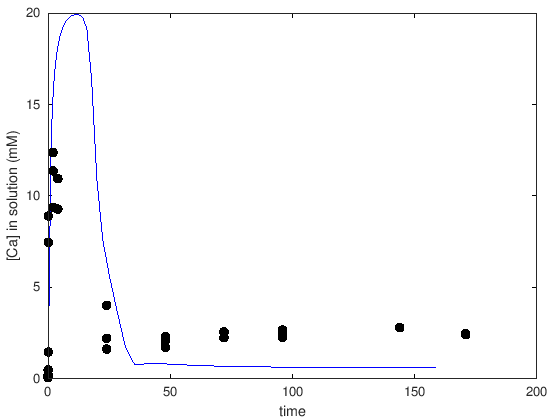

In [49]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

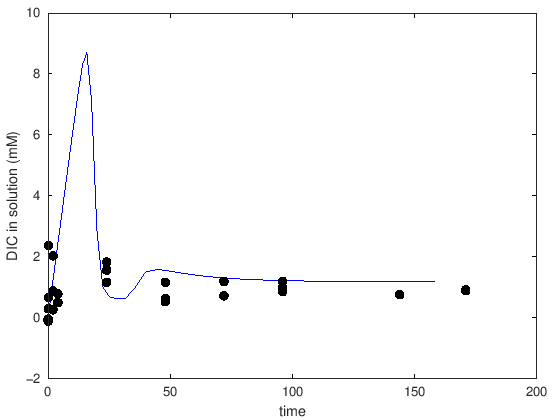

In [50]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

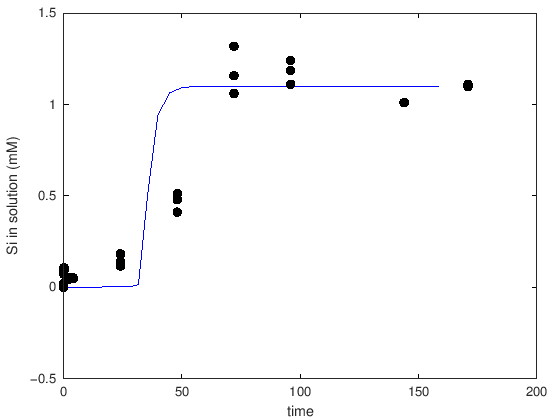

In [51]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

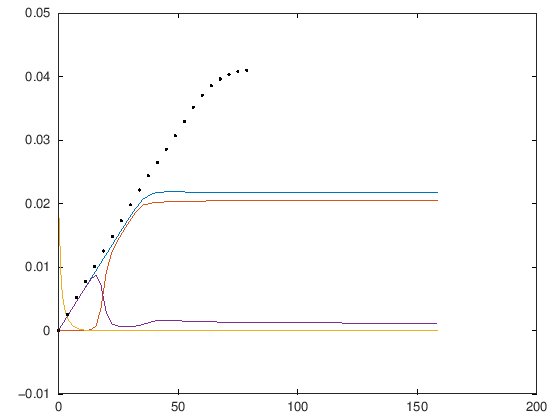

In [52]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',2)


data=[...
5	0.083333333	478		5.67837E-05	5.77583E-05	-0.00000097466 	-1.0 	-11.7 	-1.0 
10	0.166666667	259		5.89855E-05	3.12958E-05	0.00002768965 	27.7 	332.3 	26.7 
15	0.25	121		5.73631E-05	1.46208E-05	0.00004274226 	42.7 	512.9 	69.5 
20	0.333333333	56		5.95649E-05	6.76667E-06	0.00005279824 	52.8 	633.6 	122.3 
25	0.416666667	24		6.02602E-05	0.0000029	0.00005736022 	57.4 	688.3 	179.6 
30	0.5	20		6.06079E-05	2.41667E-06	0.00005819121 	58.2 	698.3 	237.8 
35	0.583333333	9		5.66678E-05	1.0875E-06	0.00005558029 	55.6 	667.0 	293.4 
40	0.666666667	14		5.78266E-05	1.69167E-06	0.00005613497 	56.1 	673.6 	349.5 
45	0.75	7		5.97967E-05	8.45833E-07	0.00005895085 	59.0 	707.4 	408.5 
50	0.833333333	16		5.89855E-05	1.93333E-06	0.00005705215 	57.1 	684.6 	465.5 
55	0.916666667	8		5.91014E-05	9.66667E-07	0.00005813470 	58.1 	697.6 	523.7 
60	1	14		5.96808E-05	1.69167E-06	0.00005798913 	58.0 	695.9 	581.6 
65	1.083333333	9		5.82902E-05	1.0875E-06	0.00005720268 	57.2 	686.4 	638.9 
70	1.166666667	12		5.82902E-05	0.00000145	0.00005684018 	56.8 	682.1 	695.7 
75	1.25	9		6.02602E-05	1.0875E-06	0.00005917272 	59.2 	710.1 	754.9 
80	1.333333333	5		6.29256E-05	6.04167E-07	0.00006232141 	62.3 	747.9 	817.2 
85	1.416666667	11		5.99126E-05	1.32917E-06	0.00005858340 	58.6 	703.0 	875.8 
90	1.5	14		5.71313E-05	1.69167E-06	0.00005543966 	55.4 	665.3 	931.2 
95	1.583333333	10		5.80584E-05	1.20833E-06	0.00005685007 	56.9 	682.2 	988.1 
100	1.666666667	11		6.01443E-05	1.32917E-06	0.00005881517 	58.8 	705.8 	1046.9 
105	1.75	12		5.92173E-05	0.00000145	0.00005776726 	57.8 	693.2 	1104.6 
110	1.833333333	13		5.84061E-05	1.57083E-06	0.00005683523 	56.8 	682.0 	1161.5 
115	1.916666667	3		5.91014E-05	3.625E-07	0.00005873887 	58.7 	704.9 	1220.2 
120	2	8		5.92173E-05	9.66667E-07	0.00005825059 	58.3 	699.0 	1278.5 
125	2.083333333	1		5.92173E-05	1.20833E-07	0.00005909642 	59.1 	709.2 	1337.6 
130	2.166666667	11		6.06079E-05	1.32917E-06	0.00005927871 	59.3 	711.3 	1396.8 
135	2.25	13		6.10714E-05	1.57083E-06	0.00005950058 	59.5 	714.0 	1456.3 
140	2.333333333	8		5.99126E-05	9.66667E-07	0.00005894590 	58.9 	707.4 	1515.3 
145	2.416666667	17		5.84061E-05	2.05417E-06	0.00005635189 	56.4 	676.2 	1571.6 
150	2.5	11		5.79425E-05	1.32917E-06	0.00005661335 	56.6 	679.4 	1628.3 
155	2.583333333	6		5.82902E-05	0.000000725	0.00005756518 	57.6 	690.8 	1685.8 
160	2.666666667	13		6.13032E-05	1.57083E-06	0.00005973235 	59.7 	716.8 	1745.6 
165	2.75	18		5.78266E-05	0.000002175	0.00005565164 	55.7 	667.8 	1801.2 
170	2.833333333	8		5.99126E-05	9.66667E-07	0.00005894590 	58.9 	707.4 	1860.1 
175	2.916666667	6		5.91014E-05	0.000000725	0.00005837637 	58.4 	700.5 	1918.5 
180	3	16		5.88696E-05	1.93333E-06	0.00005693627 	56.9 	683.2 	1975.5 
185	3.083333333	12		5.81743E-05	0.00000145	0.00005672429 	56.7 	680.7 	2032.2 
190	3.166666667	11		5.93331E-05	1.32917E-06	0.00005800397 	58.0 	696.0 	2090.2 
195	3.25	16		5.9449E-05	1.93333E-06	0.00005751569 	57.5 	690.2 	2147.7 
200	3.333333333	9		5.79425E-05	1.0875E-06	0.00005685502 	56.9 	682.3 	2204.6 
205	3.416666667	12		5.82902E-05	0.00000145	0.00005684018 	56.8 	682.1 	2261.4 
210	3.5	1		5.92173E-05	1.20833E-07	0.00005909642 	59.1 	709.2 	2320.5 
215	3.583333333	12		5.88696E-05	0.00000145	0.00005741960 	57.4 	689.0 	2377.9 
220	3.666666667	21		6.07238E-05	2.5375E-06	0.00005818626 	58.2 	698.2 	2436.1 
225	3.75	9		5.86378E-05	1.0875E-06	0.00005755033 	57.6 	690.6 	2493.7 
230	3.833333333	8		5.95649E-05	9.66667E-07	0.00005859824 	58.6 	703.2 	2552.3 
235	3.916666667	18		6.14191E-05	0.000002175	0.00005924407 	59.2 	710.9 	2611.5 
240	4	5		5.68996E-05	6.04167E-07	0.00005629539 	56.3 	675.5 	2667.8 
245	4.083333333	3		5.93331E-05	3.625E-07	0.00005897064 	59.0 	707.6 	2726.8 
250	4.166666667	8		6.02602E-05	9.66667E-07	0.00005929356 	59.3 	711.5 	2786.1 
255	4.25	16		6.07238E-05	1.93333E-06	0.00005879043 	58.8 	705.5 	2844.8 
260	4.333333333	3		6.01443E-05	3.625E-07	0.00005978184 	59.8 	717.4 	2904.6 
265	4.416666667	5		5.97967E-05	6.04167E-07	0.00005919252 	59.2 	710.3 	2963.8 
270	4.5	6		5.86378E-05	0.000000725	0.00005791283 	57.9 	695.0 	3021.7 
275	4.583333333	14		5.99126E-05	1.69167E-06	0.00005822090 	58.2 	698.7 	3080.0 
280	4.666666667	9		5.79425E-05	1.0875E-06	0.00005685502 	56.9 	682.3 	3136.8 
285	4.75	5		6.06079E-05	6.04167E-07	0.00006000371 	60.0 	720.0 	3196.8 
290	4.833333333	10		6.08396E-05	1.20833E-06	0.00005963131 	59.6 	715.6 	3256.4 
295	4.916666667	9		5.85219E-05	1.0875E-06	0.00005743445 	57.4 	689.2 	3313.9 
300	5	4		6.14191E-05	4.83333E-07	0.00006093574 	60.9 	731.2 	3374.8 
305	5.083333333	2		6.16508E-05	2.41667E-07	0.00006140918 	61.4 	736.9 	3436.2 
310	5.166666667	8		5.96808E-05	9.66667E-07	0.00005871413 	58.7 	704.6 	3494.9 
315	5.25	8		6.08396E-05	9.66667E-07	0.00005987298 	59.9 	718.5 	3554.8 
320	5.333333333	14		6.1535E-05	1.69167E-06	0.00005984329 	59.8 	718.1 	3614.7 
325	5.416666667	10		6.10714E-05	1.20833E-06	0.00005986308 	59.9 	718.4 	3674.5 
330	5.5	15		6.26938E-05	1.8125E-06	0.00006088131 	60.9 	730.6 	3735.4 
335	5.583333333	18		6.02602E-05	0.000002175	0.00005808522 	58.1 	697.0 	3793.5 
340	5.666666667	20		5.99126E-05	2.41667E-06	0.00005749590 	57.5 	690.0 	3851.0 
345	5.75	18		6.18826E-05	0.000002175	0.00005970761 	59.7 	716.5 	3910.7 
350	5.833333333	11		6.09555E-05	1.32917E-06	0.00005962637 	59.6 	715.5 	3970.3 
355	5.916666667	12		6.22303E-05	0.00000145	0.00006078027 	60.8 	729.4 	4031.1 
360	6	11		6.36209E-05	1.32917E-06	0.00006229172 	62.3 	747.5 	4093.4 
365	6.083333333	14		6.30415E-05	1.69167E-06	0.00006134980 	61.3 	736.2 	4154.7 
370	6.166666667	14		6.29256E-05	1.69167E-06	0.00006123391 	61.2 	734.8 	4216.0 
375	6.25	14		6.38527E-05	1.69167E-06	0.00006216099 	62.2 	745.9 	4278.1 
380	6.333333333	14		6.22303E-05	1.69167E-06	0.00006053860 	60.5 	726.5 	4338.7 
385	6.416666667	14		6.1535E-05	1.69167E-06	0.00005984329 	59.8 	718.1 	4398.5 
390	6.5	14		6.37368E-05	1.69167E-06	0.00006204511 	62.0 	744.5 	4460.6 
395	6.583333333	14		6.2462E-05	1.69167E-06	0.00006077037 	60.8 	729.2 	4521.3 
400	6.666666667	14		6.42003E-05	1.69167E-06	0.00006250865 	62.5 	750.1 	4583.8 
405	6.75	14		5.95649E-05	1.69167E-06	0.00005787324 	57.9 	694.5 	4641.7 
410	6.833333333	14		6.28097E-05	1.69167E-06	0.00006111803 	61.1 	733.4 	4702.8 
415	6.916666667	14		6.28097E-05	1.69167E-06	0.00006111803 	61.1 	733.4 	4763.9 
420	7	14		6.19985E-05	1.69167E-06	0.00006030683 	60.3 	723.7 	4824.3 
425	7.083333333	14		6.09555E-05	1.69167E-06	0.00005926387 	59.3 	711.2 	4883.5 
430	7.166666667	14		5.7479E-05	1.69167E-06	0.00005578731 	55.8 	669.4 	4939.3 
435	7.25	14		5.68996E-05	1.69167E-06	0.00005520789 	55.2 	662.5 	4994.5 
440	7.333333333	14		5.93331E-05	1.69167E-06	0.00005764147 	57.6 	691.7 	5052.2 
445	7.416666667	14		6.23462E-05	1.69167E-06	0.00006065449 	60.7 	727.9 	5112.8 
450	7.5	14		6.17667E-05	1.69167E-06	0.00006007506 	60.1 	720.9 	5172.9 
455	7.583333333	14		6.29256E-05	1.69167E-06	0.00006123391 	61.2 	734.8 	5234.1 
460	7.666666667	11		5.97967E-05	1.32917E-06	0.00005846752 	58.5 	701.6 	5292.6 
465	7.75	15		6.10714E-05	1.8125E-06	0.00005925892 	59.3 	711.1 	5351.8 
470	7.833333333	7		5.84061E-05	8.45833E-07	0.00005756023 	57.6 	690.7 	5409.4 
475	7.916666667	10		5.89855E-05	1.20833E-06	0.00005777715 	57.8 	693.3 	5467.2 
480	8	9		5.7479E-05	1.0875E-06	0.00005639148 	56.4 	676.7 	5523.6 
485	8.083333333	9		5.70154E-05	1.0875E-06	0.00005592794 	55.9 	671.1 	5579.5 
490	8.166666667	6		5.80584E-05	0.000000725	0.00005733341 	57.3 	688.0 	5636.8 
495	8.25	10		5.65519E-05	1.20833E-06	0.00005534357 	55.3 	664.1 	5692.2 
500	8.333333333	10		5.57407E-05	1.20833E-06	0.00005453237 	54.5 	654.4 	5746.7 
505	8.416666667	7		5.60884E-05	8.45833E-07	0.00005524253 	55.2 	662.9 	5802.0 
510	8.5	6		5.86378E-05	0.000000725	0.00005791283 	57.9 	695.0 	5859.9 
515	8.583333333	15		5.62042E-05	1.8125E-06	0.00005439175 	54.4 	652.7 	5914.3 
520	8.666666667	10		5.53931E-05	1.20833E-06	0.00005418472 	54.2 	650.2 	5968.4 
525	8.75	9		5.62042E-05	1.0875E-06	0.00005511675 	55.1 	661.4 	6023.6 
530	8.833333333	6		5.51613E-05	0.000000725	0.00005443628 	54.4 	653.2 	6078.0 
535	8.916666667	10		5.71313E-05	1.20833E-06	0.00005592299 	55.9 	671.1 	6133.9 
540	9	9		5.85219E-05	1.0875E-06	0.00005743445 	57.4 	689.2 	6191.4 
545	9.083333333	11		5.6436E-05	1.32917E-06	0.00005510685 	55.1 	661.3 	6246.5 
550	9.166666667	16		5.78266E-05	1.93333E-06	0.00005589330 	55.9 	670.7 	6302.4 
555	9.25	14		5.6436E-05	1.69167E-06	0.00005474435 	54.7 	656.9 	6357.1 
560	9.333333333	9		5.67837E-05	1.0875E-06	0.00005569617 	55.7 	668.4 	6412.8 
565	9.416666667	12		5.63201E-05	0.00000145	0.00005487013 	54.9 	658.4 	6467.7 
570	9.5	10		5.56248E-05	1.20833E-06	0.00005441649 	54.4 	653.0 	6522.1 
575	9.583333333	18		5.72472E-05	0.000002175	0.00005507221 	55.1 	660.9 	6577.1 
580	9.666666667	16		5.66678E-05	1.93333E-06	0.00005473445 	54.7 	656.8 	6631.9 
585	9.75	7		5.60884E-05	8.45833E-07	0.00005524253 	55.2 	662.9 	6687.1 
590	9.833333333	21		5.55089E-05	2.5375E-06	0.00005297144 	53.0 	635.7 	6740.1 
595	9.916666667	14		5.43501E-05	1.69167E-06	0.00005265842 	52.7 	631.9 	6792.8 
600	10	7		5.87537E-05	8.45833E-07	0.00005790788 	57.9 	694.9 	6850.7 
605	10.08333333	11		5.67837E-05	1.32917E-06	0.00005545450 	55.5 	665.5 	6906.1 
610	10.16666667	16		5.68996E-05	1.93333E-06	0.00005496622 	55.0 	659.6 	6961.1 
615	10.25	19		5.78266E-05	2.29583E-06	0.00005553080 	55.5 	666.4 	7016.6 
620	10.33333333	23		5.38865E-05	2.77917E-06	0.00005110738 	51.1 	613.3 	7067.7 
625	10.41666667	9		5.65519E-05	1.0875E-06	0.00005546440 	55.5 	665.6 	7123.2 
630	10.5	14		5.63201E-05	1.69167E-06	0.00005462846 	54.6 	655.5 	7177.8 
635	10.58333333	11		5.43501E-05	1.32917E-06	0.00005302092 	53.0 	636.3 	7230.8 
640	10.66666667	12		5.59725E-05	0.00000145	0.00005452248 	54.5 	654.3 	7285.4 
645	10.75	6		5.43501E-05	0.000000725	0.00005362508 	53.6 	643.5 	7339.0 
650	10.83333333	9		5.68996E-05	1.0875E-06	0.00005581206 	55.8 	669.7 	7394.8 
655	10.91666667	12		5.66678E-05	0.00000145	0.00005521779 	55.2 	662.6 	7450.0 
660	11	6		5.46977E-05	0.000000725	0.00005397274 	54.0 	647.7 	7504.0 
665	11.08333333	18		5.52772E-05	0.000002175	0.00005310217 	53.1 	637.2 	7557.1 
670	11.16666667	25		5.43501E-05	3.02083E-06	0.00005132925 	51.3 	616.0 	7608.4 
675	11.25	12		5.42342E-05	0.00000145	0.00005278420 	52.8 	633.4 	7661.2 
680	11.33333333	17		5.43501E-05	2.05417E-06	0.00005229592 	52.3 	627.6 	7713.5 
685	11.41666667	27		5.4466E-05	3.2625E-06	0.00005120347 	51.2 	614.4 	7764.7 
690	11.5	15		5.42342E-05	1.8125E-06	0.00005242170 	52.4 	629.1 	7817.1 
695	11.58333333	17		5.67837E-05	2.05417E-06	0.00005472950 	54.7 	656.8 	7871.9 
700	11.66666667	6		5.68996E-05	0.000000725	0.00005617456 	56.2 	674.1 	7928.0 
705	11.75	16		5.40024E-05	1.93333E-06	0.00005206910 	52.1 	624.8 	7980.1 
710	11.83333333	20		5.24959E-05	2.41667E-06	0.00005007926 	50.1 	601.0 	8030.2 
715	11.91666667	21		5.57407E-05	2.5375E-06	0.00005320321 	53.2 	638.4 	8083.4 
720	12	22		5.22642E-05	2.65833E-06	0.00004960582 	49.6 	595.3 	8133.0 
725	12.08333333	14		5.51613E-05	1.69167E-06	0.00005346961 	53.5 	641.6 	8186.5 
730	12.16666667	24		5.63201E-05	0.0000029	0.00005342013 	53.4 	641.0 	8239.9 
735	12.25	18		5.43501E-05	0.000002175	0.00005217508 	52.2 	626.1 	8292.1 
740	12.33333333	12		5.49295E-05	0.00000145	0.00005347951 	53.5 	641.8 	8345.5 
745	12.41666667	15		5.62042E-05	1.8125E-06	0.00005439175 	54.4 	652.7 	8399.9 
750	12.5	18		5.53931E-05	0.000002175	0.00005321805 	53.2 	638.6 	8453.1 
755	12.58333333	10		5.72472E-05	1.20833E-06	0.00005603888 	56.0 	672.5 	8509.2 
760	12.66666667	15		5.4466E-05	1.8125E-06	0.00005265347 	52.7 	631.8 	8561.8 
765	12.75	8		5.38865E-05	9.66667E-07	0.00005291988 	52.9 	635.0 	8614.8 
770	12.83333333	18		5.51613E-05	0.000002175	0.00005298628 	53.0 	635.8 	8667.7 
775	12.91666667	17		5.45819E-05	2.05417E-06	0.00005252769 	52.5 	630.3 	8720.3 
780	13	15		5.21483E-05	1.8125E-06	0.00005033577 	50.3 	604.0 	8770.6 
785	13.08333333	15		5.75949E-05	1.8125E-06	0.00005578237 	55.8 	669.4 	8826.4 
790	13.16666667	23		5.38865E-05	2.77917E-06	0.00005110738 	51.1 	613.3 	8877.5 
795	13.25	16		5.48136E-05	1.93333E-06	0.00005288029 	52.9 	634.6 	8930.4 
800	13.33333333	15		5.48136E-05	1.8125E-06	0.00005300112 	53.0 	636.0 	8983.4 
805	13.41666667	15		5.37707E-05	1.8125E-06	0.00005195816 	52.0 	623.5 	9035.3 
810	13.5	15		5.4466E-05	1.8125E-06	0.00005265347 	52.7 	631.8 	9088.0 
815	13.58333333	11		5.59725E-05	1.32917E-06	0.00005464331 	54.6 	655.7 	9142.6 
820	13.66666667	26		5.50454E-05	3.14167E-06	0.00005190373 	51.9 	622.8 	9194.5 
825	13.75	23		5.51613E-05	2.77917E-06	0.00005238211 	52.4 	628.6 	9246.9 
830	13.83333333	15		5.91014E-05	1.8125E-06	0.00005728887 	57.3 	687.5 	9304.2 
835	13.91666667	23		5.49295E-05	2.77917E-06	0.00005215034 	52.2 	625.8 	9356.4 
840	14	14		5.84061E-05	1.69167E-06	0.00005671439 	56.7 	680.6 	9413.1 
845	14.08333333	11		5.71313E-05	1.32917E-06	0.00005580216 	55.8 	669.6 	9468.9 
850	14.16666667	18		5.70154E-05	0.000002175	0.00005484044 	54.8 	658.1 	9523.7 
855	14.25	18		5.60884E-05	0.000002175	0.00005391336 	53.9 	647.0 	9577.6 
860	14.33333333	21		5.6436E-05	2.5375E-06	0.00005389852 	53.9 	646.8 	9631.5 
865	14.41666667	24		5.79425E-05	0.0000029	0.00005504252 	55.0 	660.5 	9686.6 
870	14.5	31		5.85219E-05	3.74583E-06	0.00005477611 	54.8 	657.3 	9741.3 
875	14.58333333	20		5.65519E-05	2.41667E-06	0.00005413523 	54.1 	649.6 	9795.5 
880	14.66666667	17		5.67837E-05	2.05417E-06	0.00005472950 	54.7 	656.8 	9850.2 
885	14.75	24		5.6436E-05	0.0000029	0.00005353602 	53.5 	642.4 	9903.7 
890	14.83333333	21		5.41183E-05	2.5375E-06	0.00005158081 	51.6 	619.0 	9955.3 
895	14.91666667	30		5.59725E-05	0.000003625	0.00005234748 	52.3 	628.2 	10007.7 
900	15	19		5.65519E-05	2.29583E-06	0.00005425607 	54.3 	651.1 	10061.9 
905	15.08333333	22		5.71313E-05	2.65833E-06	0.00005447299 	54.5 	653.7 	10116.4 
910	15.16666667	26		5.51613E-05	3.14167E-06	0.00005201961 	52.0 	624.2 	10168.4 
915	15.25	19		5.6436E-05	2.29583E-06	0.00005414018 	54.1 	649.7 	10222.6 
920	15.33333333	24		5.56248E-05	0.0000029	0.00005272482 	52.7 	632.7 	10275.3 
925	15.41666667	28		5.65519E-05	3.38333E-06	0.00005316857 	53.2 	638.0 	10328.5 
930	15.5	20		5.51613E-05	2.41667E-06	0.00005274461 	52.7 	632.9 	10381.2 
935	15.58333333	17		5.66678E-05	2.05417E-06	0.00005461362 	54.6 	655.4 	10435.8 
940	15.66666667	23		5.43501E-05	2.77917E-06	0.00005157092 	51.6 	618.9 	10487.4 
945	15.75	33		5.63201E-05	3.9875E-06	0.00005233263 	52.3 	628.0 	10539.7 
950	15.83333333	26		5.58566E-05	3.14167E-06	0.00005271492 	52.7 	632.6 	10592.4 
955	15.91666667	26		5.52772E-05	3.14167E-06	0.00005213550 	52.1 	625.6 	10644.6 
960	16	21		5.71313E-05	2.5375E-06	0.00005459383 	54.6 	655.1 	10699.2 
965	16.08333333	26		5.78266E-05	3.14167E-06	0.00005468497 	54.7 	656.2 	10753.8 
970	16.16666667	29		5.78266E-05	3.50417E-06	0.00005432247 	54.3 	651.9 	10808.2 
975	16.25	17		5.59725E-05	2.05417E-06	0.00005391831 	53.9 	647.0 	10862.1 
980	16.33333333	35		5.79425E-05	4.22917E-06	0.00005371335 	53.7 	644.6 	10915.8 
985	16.41666667	23		5.73631E-05	2.77917E-06	0.00005458393 	54.6 	655.0 	10970.4 
990	16.5	17		5.57407E-05	2.05417E-06	0.00005368654 	53.7 	644.2 	11024.1 
995	16.58333333	26		5.4466E-05	3.14167E-06	0.00005132430 	51.3 	615.9 	11075.4 
1000	16.66666667	30		5.57407E-05	0.000003625	0.00005211571 	52.1 	625.4 	11127.5 
1005	16.75	22		5.80584E-05	2.65833E-06	0.00005540007 	55.4 	664.8 	11182.9 
1010	16.83333333	16		5.80584E-05	1.93333E-06	0.00005612507 	56.1 	673.5 	11239.0 
1015	16.91666667	18		5.84061E-05	0.000002175	0.00005623106 	56.2 	674.8 	11295.3 
1020	17	25		5.68996E-05	3.02083E-06	0.00005387872 	53.9 	646.5 	11349.1 
1025	17.08333333	29		5.50454E-05	3.50417E-06	0.00005154123 	51.5 	618.5 	11400.7 
1030	17.16666667	31		5.36548E-05	3.74583E-06	0.00004990894 	49.9 	598.9 	11450.6 
1035	17.25	16		5.66678E-05	1.93333E-06	0.00005473445 	54.7 	656.8 	11505.3 
1040	17.33333333	27		5.50454E-05	3.2625E-06	0.00005178289 	51.8 	621.4 	11557.1 
1045	17.41666667	19		5.42342E-05	2.29583E-06	0.00005193837 	51.9 	623.3 	11609.0 
1050	17.5	27		5.73631E-05	3.2625E-06	0.00005410060 	54.1 	649.2 	11663.1 
1055	17.58333333	26		5.73631E-05	3.14167E-06	0.00005422143 	54.2 	650.7 	11717.4 
1060	17.66666667	36		5.79425E-05	0.00000435	0.00005359252 	53.6 	643.1 	11771.0 
1065	17.75	30		5.57407E-05	0.000003625	0.00005211571 	52.1 	625.4 	11823.1 
1070	17.83333333	19		5.80584E-05	2.29583E-06	0.00005576257 	55.8 	669.2 	11878.8 
1075	17.91666667	29		5.66678E-05	3.50417E-06	0.00005316362 	53.2 	638.0 	11932.0 
1080	18	30		5.81743E-05	0.000003625	0.00005454929 	54.5 	654.6 	11986.6 
1085	18.08333333	26		5.88696E-05	3.14167E-06	0.00005572793 	55.7 	668.7 	12042.3 
1090	18.16666667	31		5.80584E-05	3.74583E-06	0.00005431257 	54.3 	651.8 	12096.6 
1095	18.25	27		5.60884E-05	3.2625E-06	0.00005282586 	52.8 	633.9 	12149.4 
1100	18.33333333	24		5.67837E-05	0.0000029	0.00005388367 	53.9 	646.6 	12203.3 
1105	18.41666667	26		5.70154E-05	3.14167E-06	0.00005387377 	53.9 	646.5 	12257.2 
1110	18.5	26		5.43501E-05	3.14167E-06	0.00005120842 	51.2 	614.5 	12308.4 
1115	18.58333333	19		5.6436E-05	2.29583E-06	0.00005414018 	54.1 	649.7 	12362.5 
1120	18.66666667	33		5.59725E-05	3.9875E-06	0.00005198498 	52.0 	623.8 	12414.5 
1125	18.75	31		5.52772E-05	3.74583E-06	0.00005153133 	51.5 	618.4 	12466.0 
1130	18.83333333	33		5.79425E-05	3.9875E-06	0.00005395502 	54.0 	647.5 	12520.0 
1135	18.91666667	37		5.67837E-05	4.47083E-06	0.00005231284 	52.3 	627.8 	12572.3 
1140	19	23		5.60884E-05	2.77917E-06	0.00005330919 	53.3 	639.7 	12625.6 
1145	19.08333333	38		5.66678E-05	4.59167E-06	0.00005207612 	52.1 	624.9 	12677.7 
1150	19.16666667	39		5.66678E-05	4.7125E-06	0.00005195529 	52.0 	623.5 	12729.7 
1155	19.25	26		5.42342E-05	3.14167E-06	0.00005109253 	51.1 	613.1 	12780.7 
1160	19.33333333	27		5.72472E-05	3.2625E-06	0.00005398471 	54.0 	647.8 	12834.7 
1165	19.41666667	33		5.7479E-05	3.9875E-06	0.00005349148 	53.5 	641.9 	12888.2 
1170	19.5	28		5.49295E-05	3.38333E-06	0.00005154618 	51.5 	618.6 	12939.8 
1175	19.58333333	31		5.55089E-05	3.74583E-06	0.00005176310 	51.8 	621.2 	12991.5 
1180	19.66666667	29		5.38865E-05	3.50417E-06	0.00005038238 	50.4 	604.6 	13041.9 
1185	19.75	31		5.57407E-05	3.74583E-06	0.00005199487 	52.0 	623.9 	13093.9 
1190	19.83333333	31		5.65519E-05	3.74583E-06	0.00005280607 	52.8 	633.7 	13146.7 
1195	19.91666667	27		5.48136E-05	3.2625E-06	0.00005155112 	51.6 	618.6 	13198.3 
1200	20	34		5.78266E-05	4.10833E-06	0.00005371830 	53.7 	644.6 	13252.0 
1205	20.08333333	38		5.46977E-05	4.59167E-06	0.00005010607 	50.1 	601.3 	13302.1 
1210	20.16666667	40		5.57407E-05	4.83333E-06	0.00005090737 	50.9 	610.9 	13353.0 
1215	20.25	34		5.84061E-05	4.10833E-06	0.00005429773 	54.3 	651.6 	13407.3 
1220	20.33333333	34		5.62042E-05	4.10833E-06	0.00005209591 	52.1 	625.2 	13459.4 
1225	20.41666667	30		5.65519E-05	0.000003625	0.00005292690 	52.9 	635.1 	13512.3 
1230	20.5	40		5.49295E-05	4.83333E-06	0.00005009618 	50.1 	601.2 	13562.4 
1235	20.58333333	34		5.72472E-05	4.10833E-06	0.00005313888 	53.1 	637.7 	13615.6 
1240	20.66666667	29		5.84061E-05	3.50417E-06	0.00005490189 	54.9 	658.8 	13670.5 
1245	20.75	26		5.59725E-05	3.14167E-06	0.00005283081 	52.8 	634.0 	13723.3 
1250	20.83333333	38		5.37707E-05	4.59167E-06	0.00004917899 	49.2 	590.1 	13772.5 
1255	20.91666667	31		5.58566E-05	3.74583E-06	0.00005211076 	52.1 	625.3 	13824.6 
1260	21	24		5.48136E-05	0.0000029	0.00005191362 	51.9 	623.0 	13876.5 
1265	21.08333333	33		5.36548E-05	3.9875E-06	0.00004966727 	49.7 	596.0 	13926.2 
1270	21.16666667	35		5.55089E-05	4.22917E-06	0.00005127977 	51.3 	615.4 	13977.4 
1275	21.25	28		5.58566E-05	3.38333E-06	0.00005247326 	52.5 	629.7 	14029.9 
1280	21.33333333	34		5.68996E-05	4.10833E-06	0.00005279122 	52.8 	633.5 	14082.7 
1285	21.41666667	29		5.57407E-05	3.50417E-06	0.00005223654 	52.2 	626.8 	14134.9 
1290	21.5	29		5.57407E-05	3.50417E-06	0.00005223654 	52.2 	626.8 	14187.2 
1295	21.58333333	30		5.57407E-05	0.000003625	0.00005211571 	52.1 	625.4 	14239.3 
1300	21.66666667	34		5.6436E-05	4.10833E-06	0.00005232768 	52.3 	627.9 	14291.6 
1305	21.75	30		5.51613E-05	0.000003625	0.00005153628 	51.5 	618.4 	14343.2 
1310	21.83333333	35		5.66678E-05	4.22917E-06	0.00005243862 	52.4 	629.3 	14395.6 
1315	21.91666667	38		5.41183E-05	4.59167E-06	0.00004952665 	49.5 	594.3 	14445.1 
1320	22	36		5.71313E-05	0.00000435	0.00005278133 	52.8 	633.4 	14497.9 
1325	22.08333333	45		5.59725E-05	5.4375E-06	0.00005053498 	50.5 	606.4 	14548.4 
1330	22.16666667	29		5.57407E-05	3.50417E-06	0.00005223654 	52.2 	626.8 	14600.7 
1335	22.25	42		5.87537E-05	0.000005075	0.00005367872 	53.7 	644.1 	14654.3 
1340	22.33333333	35		5.28436E-05	4.22917E-06	0.00004861441 	48.6 	583.4 	14703.0 
1345	22.41666667	37		5.51613E-05	4.47083E-06	0.00005069045 	50.7 	608.3 	14753.7 
1350	22.5	40		5.77108E-05	4.83333E-06	0.00005287742 	52.9 	634.5 	14806.5 
1355	22.58333333	36		5.78266E-05	0.00000435	0.00005347664 	53.5 	641.7 	14860.0 
1360	22.66666667	44		5.72472E-05	5.31667E-06	0.00005193054 	51.9 	623.2 	14911.9 
1365	22.75	35		5.78266E-05	4.22917E-06	0.00005359747 	53.6 	643.2 	14965.5 
1370	22.83333333	38		5.71313E-05	4.59167E-06	0.00005253966 	52.5 	630.5 	15018.1 
1375	22.91666667	40		5.73631E-05	4.83333E-06	0.00005252976 	52.5 	630.4 	15070.6 
1380	23	43		5.80584E-05	5.19583E-06	0.00005286257 	52.9 	634.4 	15123.5 
1385	23.08333333	39		5.53931E-05	4.7125E-06	0.00005068055 	50.7 	608.2 	15174.1 
1390	23.16666667	44		5.82902E-05	5.31667E-06	0.00005297351 	53.0 	635.7 	15227.1 
1395	23.25	39		5.82902E-05	4.7125E-06	0.00005357768 	53.6 	642.9 	15280.7 
1400	23.33333333	33		5.84061E-05	3.9875E-06	0.00005441856 	54.4 	653.0 	15335.1 
1405	23.41666667	35		5.72472E-05	4.22917E-06	0.00005301804 	53.0 	636.2 	15388.1 
1410	23.5	44		5.86378E-05	5.31667E-06	0.00005332116 	53.3 	639.9 	15441.5 
1415	23.58333333	28		5.70154E-05	3.38333E-06	0.00005363211 	53.6 	643.6 	15495.1 
1420	23.66666667	37		5.84061E-05	4.47083E-06	0.00005393523 	53.9 	647.2 	15549.0 
1425	23.75	44		5.75949E-05	5.31667E-06	0.00005227820 	52.3 	627.3 	15601.3 
1430	23.83333333	36		5.72472E-05	0.00000435	0.00005289721 	52.9 	634.8 	15654.2 
1435	23.91666667	30		5.72472E-05	0.000003625	0.00005362221 	53.6 	643.5 	15707.8 
1440	24	46		5.75949E-05	5.55833E-06	0.00005203653 	52.0 	624.4 	15759.9 
1445	24.08333333	40		5.92173E-05	4.83333E-06	0.00005438392 	54.4 	652.6 	15814.2 
1450	24.16666667	27		5.95649E-05	3.2625E-06	0.00005630241 	56.3 	675.6 	15870.5 
1455	24.25	37		5.80584E-05	4.47083E-06	0.00005358757 	53.6 	643.1 	15924.1 
1460	24.33333333	43		5.97967E-05	5.19583E-06	0.00005460085 	54.6 	655.2 	15978.7 
1465	24.41666667	46		5.56248E-05	5.55833E-06	0.00005006649 	50.1 	600.8 	16028.8 
1470	24.5	38		5.52772E-05	4.59167E-06	0.00005068550 	50.7 	608.2 	16079.5 
1475	24.58333333	45		5.72472E-05	5.4375E-06	0.00005180971 	51.8 	621.7 	16131.3 
1480	24.66666667	44		6.06079E-05	5.31667E-06	0.00005529121 	55.3 	663.5 	16186.6 
1485	24.75	45		5.62042E-05	5.4375E-06	0.00005076675 	50.8 	609.2 	16237.4 
1490	24.83333333	37		6.09555E-05	4.47083E-06	0.00005648470 	56.5 	677.8 	16293.8 
1495	24.91666667	38		5.93331E-05	4.59167E-06	0.00005474147 	54.7 	656.9 	16348.6 
1500	25	43		5.72472E-05	5.19583E-06	0.00005205138 	52.1 	624.6 	16400.6 
1505	25.08333333	47		5.78266E-05	5.67917E-06	0.00005214747 	52.1 	625.8 	16452.8 
1510	25.16666667	39		5.72472E-05	4.7125E-06	0.00005253471 	52.5 	630.4 	16505.3 
1515	25.25	37		5.86378E-05	4.47083E-06	0.00005416700 	54.2 	650.0 	16559.5 
1520	25.33333333	39		5.99126E-05	4.7125E-06	0.00005520007 	55.2 	662.4 	16614.7 
1525	25.41666667	42		5.84061E-05	0.000005075	0.00005333106 	53.3 	640.0 	16668.0 
1530	25.5	38		5.87537E-05	4.59167E-06	0.00005416205 	54.2 	649.9 	16722.2 
1535	25.58333333	38		5.80584E-05	4.59167E-06	0.00005346674 	53.5 	641.6 	16775.6 
1540	25.66666667	47		5.96808E-05	5.67917E-06	0.00005400163 	54.0 	648.0 	16829.6 
1545	25.75	36		6.21144E-05	0.00000435	0.00005776438 	57.8 	693.2 	16887.4 
1550	25.83333333	47		5.82902E-05	5.67917E-06	0.00005261101 	52.6 	631.3 	16940.0 
1555	25.91666667	45		5.72472E-05	5.4375E-06	0.00005180971 	51.8 	621.7 	16991.8 
1560	26	40		6.03761E-05	4.83333E-06	0.00005554277 	55.5 	666.5 	17047.4 
1565	26.08333333	45		5.73631E-05	5.4375E-06	0.00005192560 	51.9 	623.1 	17099.3 
1570	26.16666667	45		5.70154E-05	5.4375E-06	0.00005157794 	51.6 	618.9 	17150.9 
1575	26.25	43		5.93331E-05	5.19583E-06	0.00005413731 	54.1 	649.6 	17205.0 
1580	26.33333333	40		5.95649E-05	4.83333E-06	0.00005473158 	54.7 	656.8 	17259.7 
1585	26.41666667	42		6.02602E-05	0.000005075	0.00005518522 	55.2 	662.2 	17314.9 
1590	26.5	46		6.02602E-05	5.55833E-06	0.00005470189 	54.7 	656.4 	17369.6 
1595	26.58333333	38		5.87537E-05	4.59167E-06	0.00005416205 	54.2 	649.9 	17423.8 
1600	26.66666667	49		6.21144E-05	5.92083E-06	0.00005619355 	56.2 	674.3 	17480.0 
1605	26.75	38		6.02602E-05	4.59167E-06	0.00005566856 	55.7 	668.0 	17535.7 
1610	26.83333333	42		5.82902E-05	0.000005075	0.00005321518 	53.2 	638.6 	17588.9 
1615	26.91666667	37		5.77108E-05	4.47083E-06	0.00005323992 	53.2 	638.9 	17642.1 
1620	27	48		6.14191E-05	0.0000058	0.00005561907 	55.6 	667.4 	17697.7 
1625	27.08333333	49		6.17667E-05	5.92083E-06	0.00005584589 	55.8 	670.2 	17753.6 
1630	27.16666667	49		6.32732E-05	5.92083E-06	0.00005735240 	57.4 	688.2 	17810.9 
1635	27.25	49		6.02602E-05	5.92083E-06	0.00005433939 	54.3 	652.1 	17865.3 
1640	27.33333333	42		6.00285E-05	0.000005075	0.00005495345 	55.0 	659.4 	17920.2 
1645	27.41666667	50		6.01443E-05	6.04167E-06	0.00005410267 	54.1 	649.2 	17974.3 
1650	27.5	44		6.29256E-05	5.31667E-06	0.00005760891 	57.6 	691.3 	18031.9 
1655	27.58333333	53		6.09555E-05	6.40417E-06	0.00005455137 	54.6 	654.6 	18086.5 
1660	27.66666667	53		6.02602E-05	6.40417E-06	0.00005385606 	53.9 	646.3 	18140.3 
1665	27.75	41		6.08396E-05	4.95417E-06	0.00005588548 	55.9 	670.6 	18196.2 
1670	27.83333333	53		6.2462E-05	6.40417E-06	0.00005605787 	56.1 	672.7 	18252.3 
1675	27.91666667	43		6.23462E-05	5.19583E-06	0.00005715032 	57.2 	685.8 	18309.4 
1680	28	50		6.26938E-05	6.04167E-06	0.00005665214 	56.7 	679.8 	18366.1 
1685	28.08333333	56		6.36209E-05	6.76667E-06	0.00005685422 	56.9 	682.3 	18422.9 
1690	28.16666667	57		5.9449E-05	6.8875E-06	0.00005256153 	52.6 	630.7 	18475.5 
1695	28.25	54		6.48956E-05	0.000006525	0.00005837062 	58.4 	700.4 	18533.9 
1700	28.33333333	45		6.21144E-05	5.4375E-06	0.00005667688 	56.7 	680.1 	18590.5 
1705	28.41666667	49		6.16508E-05	5.92083E-06	0.00005573001 	55.7 	668.8 	18646.3 
1710	28.5	52		6.42003E-05	6.28333E-06	0.00005791698 	57.9 	695.0 	18704.2 
1715	28.58333333	50		6.02602E-05	6.04167E-06	0.00005421856 	54.2 	650.6 	18758.4 
1720	28.66666667	41		6.07238E-05	4.95417E-06	0.00005576960 	55.8 	669.2 	18814.2 
1725	28.75	47		6.29256E-05	5.67917E-06	0.00005724641 	57.2 	687.0 	18871.4 
1730	28.83333333	45		6.40844E-05	5.4375E-06	0.00005864693 	58.6 	703.8 	18930.1 
1735	28.91666667	51		6.26938E-05	6.1625E-06	0.00005653131 	56.5 	678.4 	18986.6 
1740	29	48		6.30415E-05	0.0000058	0.00005724146 	57.2 	686.9 	19043.8 
1745	29.08333333	44		6.21144E-05	5.31667E-06	0.00005679772 	56.8 	681.6 	19100.6 
1750	29.16666667	53		6.19985E-05	6.40417E-06	0.00005559433 	55.6 	667.1 	19156.2 
1755	29.25	47		6.32732E-05	5.67917E-06	0.00005759407 	57.6 	691.1 	19213.8 
1760	29.33333333	47		6.23462E-05	5.67917E-06	0.00005666699 	56.7 	680.0 	19270.5 
1765	29.41666667	55		6.03761E-05	6.64583E-06	0.00005373027 	53.7 	644.8 	19324.2 
1770	29.5	52		6.3505E-05	6.28333E-06	0.00005722167 	57.2 	686.7 	19381.5 
1775	29.58333333	49		6.22303E-05	5.92083E-06	0.00005630943 	56.3 	675.7 	19437.8 
1780	29.66666667	50		6.09555E-05	6.04167E-06	0.00005491387 	54.9 	659.0 	19492.7 
1785	29.75	54		6.26938E-05	0.000006525	0.00005616881 	56.2 	674.0 	19548.8 
1790	29.83333333	47		6.4548E-05	5.67917E-06	0.00005886880 	58.9 	706.4 	19607.7 
1795	29.91666667	54		6.1535E-05	0.000006525	0.00005500996 	55.0 	660.1 	19662.7 
1800	30	46		5.99126E-05	5.55833E-06	0.00005435423 	54.4 	652.3 	19717.1 
1805	30.08333333	49		6.36209E-05	5.92083E-06	0.00005770005 	57.7 	692.4 	19774.8 
1810	30.16666667	50		6.18826E-05	6.04167E-06	0.00005584095 	55.8 	670.1 	19830.6 
1815	30.25	50		6.1535E-05	6.04167E-06	0.00005549329 	55.5 	665.9 	19886.1 
1820	30.33333333	50		6.21144E-05	6.04167E-06	0.00005607272 	56.1 	672.9 	19942.2 
1825	30.41666667	49		6.31573E-05	5.92083E-06	0.00005723651 	57.2 	686.8 	19999.4 
1830	30.5	44		5.97967E-05	5.31667E-06	0.00005448002 	54.5 	653.8 	20053.9 
1835	30.58333333	47		6.01443E-05	5.67917E-06	0.00005446517 	54.5 	653.6 	20108.4 
1840	30.66666667	50		6.09555E-05	6.04167E-06	0.00005491387 	54.9 	659.0 	20163.3 
1845	30.75	51		6.06079E-05	6.1625E-06	0.00005444538 	54.4 	653.3 	20217.7 
1850	30.83333333	47		5.92173E-05	5.67917E-06	0.00005353809 	53.5 	642.5 	20271.3 
1855	30.91666667	51		5.77108E-05	6.1625E-06	0.00005154825 	51.5 	618.6 	20322.8 
1860	31	51		5.72472E-05	6.1625E-06	0.00005108471 	51.1 	613.0 	20373.9 
1865	31.08333333	47		5.92173E-05	5.67917E-06	0.00005353809 	53.5 	642.5 	20427.4 
1870	31.16666667	40		5.86378E-05	4.83333E-06	0.00005380450 	53.8 	645.7 	20481.2 
1875	31.25	49		6.14191E-05	5.92083E-06	0.00005549824 	55.5 	666.0 	20536.7 
1880	31.33333333	50		5.86378E-05	6.04167E-06	0.00005259616 	52.6 	631.2 	20589.3 
1885	31.41666667	55		5.66678E-05	6.64583E-06	0.00005002195 	50.0 	600.3 	20639.4 
1890	31.5	46		5.93331E-05	5.55833E-06	0.00005377481 	53.8 	645.3 	20693.1 
1895	31.58333333	54		5.84061E-05	0.000006525	0.00005188106 	51.9 	622.6 	20745.0 
1900	31.66666667	43		6.10714E-05	5.19583E-06	0.00005587558 	55.9 	670.5 	20800.9 
1905	31.75	48		6.0492E-05	0.0000058	0.00005469199 	54.7 	656.3 	20855.6 
1910	31.83333333	48		5.85219E-05	0.0000058	0.00005272195 	52.7 	632.7 	20908.3 
1915	31.91666667	41		5.95649E-05	4.95417E-06	0.00005461074 	54.6 	655.3 	20962.9 
1920	32	54		5.68996E-05	0.000006525	0.00005037456 	50.4 	604.5 	21013.3 
1925	32.08333333	49		5.85219E-05	5.92083E-06	0.00005260111 	52.6 	631.2 	21065.9 
1930	32.16666667	46		5.77108E-05	5.55833E-06	0.00005215242 	52.2 	625.8 	21118.0 
1935	32.25	49		5.63201E-05	5.92083E-06	0.00005039930 	50.4 	604.8 	21168.4 
1940	32.33333333	46		5.77108E-05	5.55833E-06	0.00005215242 	52.2 	625.8 	21220.6 
1945	32.41666667	52		5.51613E-05	6.28333E-06	0.00004887795 	48.9 	586.5 	21269.5 
1950	32.5	50		5.65519E-05	6.04167E-06	0.00005051023 	50.5 	606.1 	21320.0 
1955	32.58333333	61		5.66678E-05	7.37083E-06	0.00004929695 	49.3 	591.6 	21369.3 
1960	32.66666667	47		5.37707E-05	5.67917E-06	0.00004809149 	48.1 	577.1 	21417.4 
1965	32.75	42		5.40024E-05	0.000005075	0.00004892743 	48.9 	587.1 	21466.3 
1970	32.83333333	46		5.66678E-05	5.55833E-06	0.00005110945 	51.1 	613.3 	21517.4 
1975	32.91666667	42		5.75949E-05	0.000005075	0.00005251987 	52.5 	630.2 	21569.9 
1980	33	40		6.08396E-05	4.83333E-06	0.00005600631 	56.0 	672.1 	21625.9 
1985	33.08333333	52		5.7479E-05	6.28333E-06	0.00005119565 	51.2 	614.3 	21677.1 
1990	33.16666667	51		5.73631E-05	6.1625E-06	0.00005120060 	51.2 	614.4 	21728.3 
1995	33.25	53		5.81743E-05	6.40417E-06	0.00005177012 	51.8 	621.2 	21780.1 
2000	33.33333333	43		5.80584E-05	5.19583E-06	0.00005286257 	52.9 	634.4 	21833.0 
2005	33.41666667	43		5.62042E-05	5.19583E-06	0.00005100841 	51.0 	612.1 	21884.0 
2010	33.5	51		5.79425E-05	6.1625E-06	0.00005178002 	51.8 	621.4 	21935.7 
2015	33.58333333	51		5.67837E-05	6.1625E-06	0.00005062117 	50.6 	607.5 	21986.4 
2020	33.66666667	51		5.72472E-05	6.1625E-06	0.00005108471 	51.1 	613.0 	22037.5 
2025	33.75	61		5.51613E-05	7.37083E-06	0.00004779045 	47.8 	573.5 	22085.2 
2030	33.83333333	58		5.53931E-05	7.00833E-06	0.00004838472 	48.4 	580.6 	22133.6 
2035	33.91666667	45		5.65519E-05	5.4375E-06	0.00005111440 	51.1 	613.4 	22184.7 
2040	34	58		5.75949E-05	7.00833E-06	0.00005058653 	50.6 	607.0 	22235.3 
2045	34.08333333	53		5.56248E-05	6.40417E-06	0.00004922065 	49.2 	590.6 	22284.6 
2050	34.16666667	53		5.45819E-05	6.40417E-06	0.00004817769 	48.2 	578.1 	22332.7 
2055	34.25	60		5.67837E-05	0.00000725	0.00004953367 	49.5 	594.4 	22382.3 
2060	34.33333333	56		5.52772E-05	6.76667E-06	0.00004851050 	48.5 	582.1 	22430.8 
2065	34.41666667	56		5.57407E-05	6.76667E-06	0.00004897404 	49.0 	587.7 	22479.7 
2070	34.5	59		5.6436E-05	7.12917E-06	0.00004930685 	49.3 	591.7 	22529.1 
2075	34.58333333	58		5.6436E-05	7.00833E-06	0.00004942768 	49.4 	593.1 	22578.5 
2080	34.66666667	54		5.56248E-05	0.000006525	0.00004909982 	49.1 	589.2 	22627.6 
2085	34.75	55		5.70154E-05	6.64583E-06	0.00005036961 	50.4 	604.4 	22677.9 
2090	34.83333333	40		5.75949E-05	4.83333E-06	0.00005276153 	52.8 	633.1 	22730.7 
2095	34.91666667	49		5.4466E-05	5.92083E-06	0.00004854514 	48.5 	582.5 	22779.3 
2100	35	39		5.77108E-05	4.7125E-06	0.00005299825 	53.0 	636.0 	22832.3 
2105	35.08333333	52		5.46977E-05	6.28333E-06	0.00004841441 	48.4 	581.0 	22880.7 
2110	35.16666667	46		5.75949E-05	5.55833E-06	0.00005203653 	52.0 	624.4 	22932.7 
2115	35.25	46		5.60884E-05	5.55833E-06	0.00005053003 	50.5 	606.4 	22983.2 
2120	35.33333333	53		5.37707E-05	6.40417E-06	0.00004736649 	47.4 	568.4 	23030.6 
2125	35.41666667	54		5.40024E-05	0.000006525	0.00004747743 	47.5 	569.7 	23078.1 
2130	35.5	53		5.35389E-05	6.40417E-06	0.00004713472 	47.1 	565.6 	23125.2 
2135	35.58333333	46		5.50454E-05	5.55833E-06	0.00004948706 	49.5 	593.8 	23174.7 
2140	35.66666667	52		5.41183E-05	6.28333E-06	0.00004783498 	47.8 	574.0 	23222.5 
2145	35.75	48		5.72472E-05	0.0000058	0.00005144721 	51.4 	617.4 	23274.0 
2150	35.83333333	45		5.66678E-05	5.4375E-06	0.00005123029 	51.2 	614.8 	23325.2 
2155	35.91666667	42		5.66678E-05	0.000005075	0.00005159279 	51.6 	619.1 	23376.8 
2160	36	46		5.36548E-05	5.55833E-06	0.00004809644 	48.1 	577.2 	23424.9 
2165	36.08333333	59		5.67837E-05	7.12917E-06	0.00004965450 	49.7 	595.9 	23474.6 
2170	36.16666667	56		5.48136E-05	6.76667E-06	0.00004804696 	48.0 	576.6 	23522.6 
2175	36.25	43		5.48136E-05	5.19583E-06	0.00004961779 	49.6 	595.4 	23572.2 
2180	36.33333333	55		5.62042E-05	6.64583E-06	0.00004955841 	49.6 	594.7 	23621.8 
2185	36.41666667	63		5.55089E-05	7.6125E-06	0.00004789644 	47.9 	574.8 	23669.7 
2190	36.5	49		5.4466E-05	5.92083E-06	0.00004854514 	48.5 	582.5 	23718.2 
2195	36.58333333	57		5.48136E-05	6.8875E-06	0.00004792612 	47.9 	575.1 	23766.1 
2200	36.66666667	58		5.48136E-05	7.00833E-06	0.00004780529 	47.8 	573.7 	23814.0 
2205	36.75	59		5.67837E-05	7.12917E-06	0.00004965450 	49.7 	595.9 	23863.6 
2210	36.83333333	54		5.55089E-05	0.000006525	0.00004898394 	49.0 	587.8 	23912.6 
2215	36.91666667	59		5.43501E-05	7.12917E-06	0.00004722092 	47.2 	566.7 	23959.8 
2220	37	54		5.42342E-05	0.000006525	0.00004770920 	47.7 	572.5 	24007.5 
2225	37.08333333	59		5.46977E-05	7.12917E-06	0.00004756857 	47.6 	570.8 	24055.1 
2230	37.16666667	54		5.4466E-05	0.000006525	0.00004794097 	47.9 	575.3 	24103.0 
2235	37.25	47		5.6436E-05	5.67917E-06	0.00005075685 	50.8 	609.1 	24153.8 
2240	37.33333333	51		5.37707E-05	6.1625E-06	0.00004760816 	47.6 	571.3 	24201.4 
2245	37.41666667	55		5.46977E-05	6.64583E-06	0.00004805191 	48.1 	576.6 	24249.4 
2250	37.5	52		5.68996E-05	6.28333E-06	0.00005061622 	50.6 	607.4 	24300.1 
2255	37.58333333	51		5.53931E-05	6.1625E-06	0.00004923055 	49.2 	590.8 	24349.3 
2260	37.66666667	57		5.43501E-05	6.8875E-06	0.00004746258 	47.5 	569.6 	24396.8 
2265	37.75	58		5.52772E-05	7.00833E-06	0.00004826883 	48.3 	579.2 	24445.0 
2270	37.83333333	43		5.41183E-05	5.19583E-06	0.00004892248 	48.9 	587.1 	24493.9 
2275	37.91666667	57		5.48136E-05	6.8875E-06	0.00004792612 	47.9 	575.1 	24541.9 
2280	38	58		5.42342E-05	7.00833E-06	0.00004722587 	47.2 	566.7 	24589.1 
2285	38.08333333	62		5.60884E-05	7.49167E-06	0.00004859669 	48.6 	583.2 	24637.7 
2290	38.16666667	56		5.66678E-05	6.76667E-06	0.00004990112 	49.9 	598.8 	24687.6 
2295	38.25	49		5.51613E-05	5.92083E-06	0.00004924045 	49.2 	590.9 	24736.8 
2300	38.33333333	64		5.28436E-05	7.73333E-06	0.00004511025 	45.1 	541.3 	24782.0 
2305	38.41666667	52		5.46977E-05	6.28333E-06	0.00004841441 	48.4 	581.0 	24830.4 
2310	38.5	49		5.51613E-05	5.92083E-06	0.00004924045 	49.2 	590.9 	24879.6 
2315	38.58333333	46		5.70154E-05	5.55833E-06	0.00005145711 	51.5 	617.5 	24931.1 
2320	38.66666667	52		5.24959E-05	6.28333E-06	0.00004621259 	46.2 	554.6 	24977.3 
2325	38.75	57		5.41183E-05	6.8875E-06	0.00004723081 	47.2 	566.8 	25024.5 
2330	38.83333333	59		5.45819E-05	7.12917E-06	0.00004745269 	47.5 	569.4 	25072.0 
2335	38.91666667	60		5.56248E-05	0.00000725	0.00004837482 	48.4 	580.5 	25120.3 
2340	39	52		5.56248E-05	6.28333E-06	0.00004934149 	49.3 	592.1 	25169.7 
2345	39.08333333	63		5.50454E-05	7.6125E-06	0.00004743289 	47.4 	569.2 	25217.1 
2350	39.16666667	50		5.4466E-05	6.04167E-06	0.00004842430 	48.4 	581.1 	25265.5 
2355	39.25	57		5.46977E-05	6.8875E-06	0.00004781024 	47.8 	573.7 	25313.3 
2360	39.33333333	59		5.43501E-05	7.12917E-06	0.00004722092 	47.2 	566.7 	25360.6 
2365	39.41666667	56		5.49295E-05	6.76667E-06	0.00004816284 	48.2 	578.0 	25408.7 
2370	39.5	57		5.59725E-05	6.8875E-06	0.00004908498 	49.1 	589.0 	25457.8 
2375	39.58333333	56		5.19165E-05	6.76667E-06	0.00004514983 	45.1 	541.8 	25503.0 
2380	39.66666667	56		5.50454E-05	6.76667E-06	0.00004827873 	48.3 	579.3 	25551.2 
2385	39.75	59		5.36548E-05	7.12917E-06	0.00004652561 	46.5 	558.3 	25597.8 
2390	39.83333333	51		5.46977E-05	6.1625E-06	0.00004853524 	48.5 	582.4 	25646.3 
2395	39.91666667	55		5.42342E-05	6.64583E-06	0.00004758837 	47.6 	571.1 	25693.9 
2400	40	50		5.38865E-05	6.04167E-06	0.00004784488 	47.8 	574.1 	25741.7 
2405	40.08333333	57		5.60884E-05	6.8875E-06	0.00004920086 	49.2 	590.4 	25790.9 
2410	40.16666667	50		5.28436E-05	6.04167E-06	0.00004680191 	46.8 	561.6 	25837.7 
2415	40.25	48		5.35389E-05	0.0000058	0.00004773889 	47.7 	572.9 	25885.5 
2420	40.33333333	52		5.67837E-05	6.28333E-06	0.00005050034 	50.5 	606.0 	25936.0 
2425	40.41666667	53		5.31912E-05	6.40417E-06	0.00004678707 	46.8 	561.4 	25982.8 
2430	40.5	57		5.60884E-05	6.8875E-06	0.00004920086 	49.2 	590.4 	26032.0 
2435	40.58333333	61		5.42342E-05	7.37083E-06	0.00004686337 	46.9 	562.4 	26078.8 
2440	40.66666667	49		5.37707E-05	5.92083E-06	0.00004784983 	47.8 	574.2 	26126.7 
2445	40.75	52		5.28436E-05	6.28333E-06	0.00004656025 	46.6 	558.7 	26173.2 
2450	40.83333333	53		5.43501E-05	6.40417E-06	0.00004794592 	47.9 	575.4 	26221.2 
2455	40.91666667	54		5.20324E-05	0.000006525	0.00004550738 	45.5 	546.1 	26266.7 
2460	41	49		5.19165E-05	5.92083E-06	0.00004599567 	46.0 	551.9 	26312.7 
2465	41.08333333	61		5.27277E-05	7.37083E-06	0.00004535686 	45.4 	544.3 	26358.0 
2470	41.16666667	61		5.38865E-05	7.37083E-06	0.00004651571 	46.5 	558.2 	26404.6 
2475	41.25	60		5.4466E-05	0.00000725	0.00004721597 	47.2 	566.6 	26451.8 
2480	41.33333333	56		5.35389E-05	6.76667E-06	0.00004677222 	46.8 	561.3 	26498.5 
2485	41.41666667	61		5.45819E-05	7.37083E-06	0.00004721102 	47.2 	566.5 	26545.8 
2490	41.5	58		5.21483E-05	7.00833E-06	0.00004513994 	45.1 	541.7 	26590.9 
2495	41.58333333	50		5.19165E-05	6.04167E-06	0.00004587483 	45.9 	550.5 	26636.8 
2500	41.66666667	65		5.50454E-05	7.85417E-06	0.00004719123 	47.2 	566.3 	26684.0 
2505	41.75	60		5.38865E-05	0.00000725	0.00004663654 	46.6 	559.6 	26730.6 
2510	41.83333333	67		5.30753E-05	8.09583E-06	0.00004497952 	45.0 	539.8 	26775.6 
2515	41.91666667	47		5.40024E-05	5.67917E-06	0.00004832326 	48.3 	579.9 	26823.9 
2520	42	64		5.42342E-05	7.73333E-06	0.00004650087 	46.5 	558.0 	26870.4 
2525	42.08333333	59		5.43501E-05	7.12917E-06	0.00004722092 	47.2 	566.7 	26917.6 
2530	42.16666667	56		5.13371E-05	6.76667E-06	0.00004457041 	44.6 	534.8 	26962.2 
2535	42.25	54		5.33071E-05	0.000006525	0.00004678212 	46.8 	561.4 	27009.0 
2540	42.33333333	54		5.3423E-05	0.000006525	0.00004689800 	46.9 	562.8 	27055.9 
2545	42.41666667	50		5.41183E-05	6.04167E-06	0.00004807665 	48.1 	576.9 	27104.0 
2550	42.5	48		5.35389E-05	0.0000058	0.00004773889 	47.7 	572.9 	27151.7 
2555	42.58333333	63		5.43501E-05	7.6125E-06	0.00004673758 	46.7 	560.9 	27198.4 
2560	42.66666667	49		5.19165E-05	5.92083E-06	0.00004599567 	46.0 	551.9 	27244.4 
2565	42.75	65		5.42342E-05	7.85417E-06	0.00004638003 	46.4 	556.6 	27290.8 
2570	42.83333333	72		5.21483E-05	0.0000087	0.00004344827 	43.4 	521.4 	27334.3 
2575	42.91666667	58		5.51613E-05	7.00833E-06	0.00004815295 	48.2 	577.8 	27382.4 
2580	43	63		5.12212E-05	7.6125E-06	0.00004360869 	43.6 	523.3 	27426.0 
2585	43.08333333	53		5.09894E-05	6.40417E-06	0.00004458525 	44.6 	535.0 	27470.6 
2590	43.16666667	61		5.30753E-05	7.37083E-06	0.00004570452 	45.7 	548.5 	27516.3 
2595	43.25	72		5.38865E-05	0.0000087	0.00004518654 	45.2 	542.2 	27561.5 
2600	43.33333333	60		5.31912E-05	0.00000725	0.00004594123 	45.9 	551.3 	27607.4 
2605	43.41666667	58		5.35389E-05	7.00833E-06	0.00004653056 	46.5 	558.4 	27654.0 
2610	43.5	65		5.238E-05	7.85417E-06	0.00004452587 	44.5 	534.3 	27698.5 
2615	43.58333333	60		5.51613E-05	0.00000725	0.00004791128 	47.9 	574.9 	27746.4 
2620	43.66666667	63		5.58566E-05	7.6125E-06	0.00004824409 	48.2 	578.9 	27794.6 
2625	43.75	64		5.38865E-05	7.73333E-06	0.00004615321 	46.2 	553.8 	27840.8 
2630	43.83333333	66		5.238E-05	0.000007975	0.00004440504 	44.4 	532.9 	27885.2 
2635	43.91666667	55		5.37707E-05	6.64583E-06	0.00004712483 	47.1 	565.5 	27932.3 
2640	44	56		5.28436E-05	6.76667E-06	0.00004607691 	46.1 	552.9 	27978.4 
2645	44.08333333	54		5.13371E-05	0.000006525	0.00004481207 	44.8 	537.7 	28023.2 
2650	44.16666667	55		5.20324E-05	6.64583E-06	0.00004538655 	45.4 	544.6 	28068.6 
2655	44.25	59		5.33071E-05	7.12917E-06	0.00004617795 	46.2 	554.1 	28114.8 
2660	44.33333333	59		5.35389E-05	7.12917E-06	0.00004640972 	46.4 	556.9 	28161.2 
2665	44.41666667	71		5.37707E-05	8.57917E-06	0.00004519149 	45.2 	542.3 	28206.4 
2670	44.5	59		5.43501E-05	7.12917E-06	0.00004722092 	47.2 	566.7 	28253.6 
2675	44.58333333	53		5.33071E-05	6.40417E-06	0.00004690295 	46.9 	562.8 	28300.5 
2680	44.66666667	58		5.63201E-05	7.00833E-06	0.00004931180 	49.3 	591.7 	28349.8 
2685	44.75	50		5.3423E-05	6.04167E-06	0.00004738134 	47.4 	568.6 	28397.2 
2690	44.83333333	53		5.35389E-05	6.40417E-06	0.00004713472 	47.1 	565.6 	28444.3 
2695	44.91666667	59		5.18006E-05	7.12917E-06	0.00004467145 	44.7 	536.1 	28489.0 
2700	45	58		5.46977E-05	7.00833E-06	0.00004768941 	47.7 	572.3 	28536.7 
2705	45.08333333	55		5.37707E-05	6.64583E-06	0.00004712483 	47.1 	565.5 	28583.8 
2710	45.16666667	62		5.18006E-05	7.49167E-06	0.00004430895 	44.3 	531.7 	28628.1 
2715	45.25	67		5.45819E-05	8.09583E-06	0.00004648602 	46.5 	557.8 	28674.6 
2720	45.33333333	64		5.27277E-05	7.73333E-06	0.00004499436 	45.0 	539.9 	28719.6 
2725	45.41666667	64		5.42342E-05	7.73333E-06	0.00004650087 	46.5 	558.0 	28766.1 
2730	45.5	55		5.38865E-05	6.64583E-06	0.00004724071 	47.2 	566.9 	28813.3 
2735	45.58333333	54		5.28436E-05	0.000006525	0.00004631858 	46.3 	555.8 	28859.7 
2740	45.66666667	64		5.63201E-05	7.73333E-06	0.00004858680 	48.6 	583.0 	28908.3 
2745	45.75	59		5.18006E-05	7.12917E-06	0.00004467145 	44.7 	536.1 	28952.9 
2750	45.83333333	52		5.46977E-05	6.28333E-06	0.00004841441 	48.4 	581.0 	29001.3 
2755	45.91666667	60		5.41183E-05	0.00000725	0.00004686831 	46.9 	562.4 	29048.2 
2760	46	56		5.16847E-05	6.76667E-06	0.00004491806 	44.9 	539.0 	29093.1 
2765	46.08333333	55		5.33071E-05	6.64583E-06	0.00004666129 	46.7 	559.9 	29139.8 
2770	46.16666667	51		5.42342E-05	6.1625E-06	0.00004807170 	48.1 	576.9 	29187.9 
2775	46.25	51		5.20324E-05	6.1625E-06	0.00004586988 	45.9 	550.4 	29233.7 
2780	46.33333333	56		5.33071E-05	6.76667E-06	0.00004654045 	46.5 	558.5 	29280.3 
2785	46.41666667	51		5.45819E-05	6.1625E-06	0.00004841935 	48.4 	581.0 	29328.7 
2790	46.5	53		5.35389E-05	6.40417E-06	0.00004713472 	47.1 	565.6 	29375.8 
2795	46.58333333	67		5.36548E-05	8.09583E-06	0.00004555894 	45.6 	546.7 	29421.4 
2800	46.66666667	66		5.21483E-05	0.000007975	0.00004417327 	44.2 	530.1 	29465.6 
2805	46.75	65		5.43501E-05	7.85417E-06	0.00004649592 	46.5 	558.0 	29512.1 
2810	46.83333333	60		5.43501E-05	0.00000725	0.00004710008 	47.1 	565.2 	29559.2 
2815	46.91666667	74		5.38865E-05	8.94167E-06	0.00004494488 	44.9 	539.3 	29604.1 
2820	47	64		5.46977E-05	7.73333E-06	0.00004696441 	47.0 	563.6 	29651.1 
2825	47.08333333	62		5.48136E-05	7.49167E-06	0.00004732196 	47.3 	567.9 	29698.4 
2830	47.16666667	63		5.50454E-05	7.6125E-06	0.00004743289 	47.4 	569.2 	29745.8 
2835	47.25	72		5.66678E-05	0.0000087	0.00004796779 	48.0 	575.6 	29793.8 
2840	47.33333333	72		5.42342E-05	0.0000087	0.00004553420 	45.5 	546.4 	29839.3 
2845	47.41666667	75		5.53931E-05	9.0625E-06	0.00004633055 	46.3 	556.0 	29885.6 
2850	47.5	63		5.36548E-05	7.6125E-06	0.00004604227 	46.0 	552.5 	29931.7 
2855	47.58333333	65		5.56248E-05	7.85417E-06	0.00004777065 	47.8 	573.2 	29979.5 
2860	47.66666667	68		5.67837E-05	8.21667E-06	0.00004856700 	48.6 	582.8 	30028.0 
2865	47.75	72		5.31912E-05	0.0000087	0.00004449123 	44.5 	533.9 	30072.5 
2870	47.83333333	66		5.57407E-05	0.000007975	0.00004776571 	47.8 	573.2 	30120.3 
2875	47.91666667	77		5.62042E-05	9.30417E-06	0.00004690008 	46.9 	562.8 	30167.2 
2880	48	79		5.31912E-05	9.54583E-06	0.00004364540 	43.6 	523.7 	30210.8 
2885	48.08333333	72		5.60884E-05	0.0000087	0.00004738836 	47.4 	568.7 	30258.2 
2890	48.16666667	80		5.60884E-05	9.66667E-06	0.00004642169 	46.4 	557.1 	30304.6 
2895	48.25	78		5.86378E-05	0.000009425	0.00004921283 	49.2 	590.6 	30353.9 
2900	48.33333333	77		5.99126E-05	9.30417E-06	0.00005060840 	50.6 	607.3 	30404.5 
2905	48.41666667	75		5.86378E-05	9.0625E-06	0.00004957533 	49.6 	594.9 	30454.0 
2910	48.5	82		5.56248E-05	9.90833E-06	0.00004571649 	45.7 	548.6 	30499.8 
2915	48.58333333	70		5.77108E-05	8.45833E-06	0.00004925242 	49.3 	591.0 	30549.0 
2920	48.66666667	67		5.58566E-05	8.09583E-06	0.00004776076 	47.8 	573.1 	30596.8 
2925	48.75	76		5.59725E-05	9.18333E-06	0.00004678914 	46.8 	561.5 	30643.6 
2930	48.83333333	70		5.81743E-05	8.45833E-06	0.00004971596 	49.7 	596.6 	30693.3 
2935	48.91666667	68		5.99126E-05	8.21667E-06	0.00005169590 	51.7 	620.4 	30745.0 
2940	49	82		5.81743E-05	9.90833E-06	0.00004826596 	48.3 	579.2 	30793.2 
2945	49.08333333	75		5.66678E-05	9.0625E-06	0.00004760529 	47.6 	571.3 	30840.8 
2950	49.16666667	72		5.78266E-05	0.0000087	0.00004912664 	49.1 	589.5 	30890.0 
2955	49.25	71		5.73631E-05	8.57917E-06	0.00004878393 	48.8 	585.4 	30938.8 
2960	49.33333333	74		5.73631E-05	8.94167E-06	0.00004842143 	48.4 	581.1 	30987.2 
2965	49.41666667	83		5.67837E-05	1.00292E-05	0.00004675450 	46.8 	561.1 	31033.9 
2970	49.5	77		5.87537E-05	9.30417E-06	0.00004944955 	49.4 	593.4 	31083.4 
2975	49.58333333	68		5.68996E-05	8.21667E-06	0.00004868289 	48.7 	584.2 	31132.1 
2980	49.66666667	76		5.71313E-05	9.18333E-06	0.00004794799 	47.9 	575.4 	31180.0 
2985	49.75	81		5.84061E-05	9.7875E-06	0.00004861856 	48.6 	583.4 	31228.6 
2990	49.83333333	80		5.67837E-05	9.66667E-06	0.00004711700 	47.1 	565.4 	31275.7 
2995	49.91666667	77		6.07238E-05	9.30417E-06	0.00005141960 	51.4 	617.0 	31327.2 
3000	50	81		5.70154E-05	9.7875E-06	0.00004722794 	47.2 	566.7 	31374.4 
3005	50.08333333	77		6.13032E-05	9.30417E-06	0.00005199902 	52.0 	624.0 	31426.4 
3010	50.16666667	78		5.73631E-05	0.000009425	0.00004793810 	47.9 	575.3 	31474.3 
3015	50.25	78		5.79425E-05	0.000009425	0.00004851752 	48.5 	582.2 	31522.8 
3020	50.33333333	77		5.79425E-05	9.30417E-06	0.00004863835 	48.6 	583.7 	31571.5 
3025	50.41666667	68		5.6436E-05	8.21667E-06	0.00004821935 	48.2 	578.6 	31619.7 
3030	50.5	80		5.87537E-05	9.66667E-06	0.00004908705 	49.1 	589.0 	31668.8 
3035	50.58333333	83		5.80584E-05	1.00292E-05	0.00004802924 	48.0 	576.4 	31716.8 
3040	50.66666667	79		5.85219E-05	9.54583E-06	0.00004897611 	49.0 	587.7 	31765.8 
3045	50.75	77		6.13032E-05	9.30417E-06	0.00005199902 	52.0 	624.0 	31817.8 
3050	50.83333333	82		5.87537E-05	9.90833E-06	0.00004884538 	48.8 	586.1 	31866.6 
3055	50.91666667	76		5.95649E-05	9.18333E-06	0.00005038158 	50.4 	604.6 	31917.0 
3060	51	77		5.85219E-05	9.30417E-06	0.00004921778 	49.2 	590.6 	31966.2 
3065	51.08333333	80		5.88696E-05	9.66667E-06	0.00004920293 	49.2 	590.4 	32015.4 
3070	51.16666667	80		5.59725E-05	9.66667E-06	0.00004630581 	46.3 	555.7 	32061.7 
3075	51.25	82		5.85219E-05	9.90833E-06	0.00004861361 	48.6 	583.4 	32110.4 
3080	51.33333333	85		6.01443E-05	1.02708E-05	0.00004987350 	49.9 	598.5 	32160.2 
3085	51.41666667	79		6.01443E-05	9.54583E-06	0.00005059850 	50.6 	607.2 	32210.8 
3090	51.5	74		5.93331E-05	8.94167E-06	0.00005039147 	50.4 	604.7 	32261.2 
3095	51.58333333	81		5.92173E-05	9.7875E-06	0.00004942976 	49.4 	593.2 	32310.7 
3100	51.66666667	70		6.03761E-05	8.45833E-06	0.00005191777 	51.9 	623.0 	32362.6 
3105	51.75	81		5.91014E-05	9.7875E-06	0.00004931387 	49.3 	591.8 	32411.9 
3110	51.83333333	78		6.14191E-05	0.000009425	0.00005199407 	52.0 	623.9 	32463.9 
3115	51.91666667	77		5.93331E-05	9.30417E-06	0.00005002897 	50.0 	600.3 	32513.9 
3120	52	74		5.87537E-05	8.94167E-06	0.00004981205 	49.8 	597.7 	32563.7 
3125	52.08333333	76		5.93331E-05	9.18333E-06	0.00005014981 	50.1 	601.8 	32613.9 
3130	52.16666667	77		5.97967E-05	9.30417E-06	0.00005049252 	50.5 	605.9 	32664.4 
3135	52.25	72		6.11873E-05	0.0000087	0.00005248730 	52.5 	629.8 	32716.9 
3140	52.33333333	71		6.0492E-05	8.57917E-06	0.00005191283 	51.9 	623.0 	32768.8 
3145	52.41666667	71		5.86378E-05	8.57917E-06	0.00005005866 	50.1 	600.7 	32818.8 
3150	52.5	79		6.23462E-05	9.54583E-06	0.00005280032 	52.8 	633.6 	32871.6 
3155	52.58333333	86		6.16508E-05	1.03917E-05	0.00005125918 	51.3 	615.1 	32922.9 
3160	52.66666667	84		6.08396E-05	0.00001015	0.00005068965 	50.7 	608.3 	32973.6 
3165	52.75	84		5.95649E-05	0.00001015	0.00004941491 	49.4 	593.0 	33023.0 
3170	52.83333333	80		5.95649E-05	9.66667E-06	0.00004989824 	49.9 	598.8 	33072.9 
3175	52.91666667	91		5.88696E-05	1.09958E-05	0.00004787377 	47.9 	574.5 	33120.8 
3180	53	83		5.89855E-05	1.00292E-05	0.00004895632 	49.0 	587.5 	33169.7 
3185	53.08333333	74		6.25779E-05	8.94167E-06	0.00005363626 	53.6 	643.6 	33223.4 
3190	53.16666667	82		5.97967E-05	9.90833E-06	0.00004988835 	49.9 	598.7 	33273.2 
3195	53.25	72		5.99126E-05	0.0000087	0.00005121257 	51.2 	614.6 	33324.5 
3200	53.33333333	84		6.00285E-05	0.00001015	0.00004987845 	49.9 	598.5 	33374.3 
3205	53.41666667	79		6.06079E-05	9.54583E-06	0.00005106204 	51.1 	612.7 	33425.4 
3210	53.5	89		5.93331E-05	1.07542E-05	0.00004857897 	48.6 	582.9 	33474.0 
3215	53.58333333	85		6.03761E-05	1.02708E-05	0.00005010527 	50.1 	601.3 	33524.1 
3220	53.66666667	79		6.23462E-05	9.54583E-06	0.00005280032 	52.8 	633.6 	33576.9 
3225	53.75	88		6.13032E-05	1.06333E-05	0.00005066985 	50.7 	608.0 	33627.5 
3230	53.83333333	77		6.18826E-05	9.30417E-06	0.00005257845 	52.6 	630.9 	33680.1 
3235	53.91666667	82		5.99126E-05	9.90833E-06	0.00005000423 	50.0 	600.1 	33730.1 
3240	54	88		6.01443E-05	1.06333E-05	0.00004951100 	49.5 	594.1 	33779.6 
3245	54.08333333	75		5.77108E-05	9.0625E-06	0.00004864825 	48.6 	583.8 	33828.3 
3250	54.16666667	89		6.2462E-05	1.07542E-05	0.00005170787 	51.7 	620.5 	33880.0 
3255	54.25	79		6.42003E-05	9.54583E-06	0.00005465448 	54.7 	655.9 	33934.7 
3260	54.33333333	89		6.09555E-05	1.07542E-05	0.00005020137 	50.2 	602.4 	33984.9 
3265	54.41666667	79		6.3505E-05	9.54583E-06	0.00005395917 	54.0 	647.5 	34038.8 
3270	54.5	83		6.33891E-05	1.00292E-05	0.00005335995 	53.4 	640.3 	34092.2 
3275	54.58333333	76		6.10714E-05	9.18333E-06	0.00005188808 	51.9 	622.7 	34144.1 
3280	54.66666667	80		6.25779E-05	9.66667E-06	0.00005291126 	52.9 	634.9 	34197.0 
3285	54.75	87		6.26938E-05	1.05125E-05	0.00005218131 	52.2 	626.2 	34249.2 
3290	54.83333333	89		6.0492E-05	1.07542E-05	0.00004973783 	49.7 	596.9 	34298.9 
3295	54.91666667	90		5.71313E-05	0.000010875	0.00004625633 	46.3 	555.1 	34345.1 
3300	55	87		5.84061E-05	1.05125E-05	0.00004789356 	47.9 	574.7 	34393.0 
3305	55.08333333	88		5.84061E-05	1.06333E-05	0.00004777273 	47.8 	573.3 	34440.8 
3310	55.16666667	81		5.84061E-05	9.7875E-06	0.00004861856 	48.6 	583.4 	34489.4 
3315	55.25	86		5.6436E-05	1.03917E-05	0.00004604435 	46.0 	552.5 	34535.5 
3320	55.33333333	80		5.84061E-05	9.66667E-06	0.00004873939 	48.7 	584.9 	34584.2 
3325	55.41666667	94		5.84061E-05	1.13583E-05	0.00004704773 	47.0 	564.6 	34631.3 
3330	55.5	89		5.75949E-05	1.07542E-05	0.00004684070 	46.8 	562.1 	34678.1 
3335	55.58333333	84		5.67837E-05	0.00001015	0.00004663367 	46.6 	559.6 	34724.7 
3340	55.66666667	93		5.73631E-05	1.12375E-05	0.00004612560 	46.1 	553.5 	34770.9 
3345	55.75	92		5.9449E-05	1.11167E-05	0.00004833236 	48.3 	580.0 	34819.2 
3350	55.83333333	83		5.72472E-05	1.00292E-05	0.00004721804 	47.2 	566.6 	34866.4 
3355	55.91666667	91		5.92173E-05	1.09958E-05	0.00004822142 	48.2 	578.7 	34914.6 
3360	56	91		5.66678E-05	1.09958E-05	0.00004567195 	45.7 	548.1 	34960.3 
3365	56.08333333	90		5.7479E-05	0.000010875	0.00004660398 	46.6 	559.2 	35006.9 
3370	56.16666667	91		5.85219E-05	1.09958E-05	0.00004752611 	47.5 	570.3 	35054.4 
3375	56.25	90		5.75949E-05	0.000010875	0.00004671987 	46.7 	560.6 	35101.2 
3380	56.33333333	81		5.97967E-05	9.7875E-06	0.00005000918 	50.0 	600.1 	35151.2 
3385	56.41666667	90		5.80584E-05	0.000010875	0.00004718341 	47.2 	566.2 	35198.3 
3390	56.5	85		5.49295E-05	1.02708E-05	0.00004465868 	44.7 	535.9 	35243.0 
3395	56.58333333	88		5.73631E-05	1.06333E-05	0.00004672976 	46.7 	560.8 	35289.7 
3400	56.66666667	85		5.57407E-05	1.02708E-05	0.00004546987 	45.5 	545.6 	35335.2 
3405	56.75	90		5.38865E-05	0.000010875	0.00004301154 	43.0 	516.1 	35378.2 
3410	56.83333333	88		5.60884E-05	1.06333E-05	0.00004545503 	45.5 	545.5 	35423.7 
3415	56.91666667	92		5.66678E-05	1.11167E-05	0.00004555112 	45.6 	546.6 	35469.2 
3420	57	83		5.77108E-05	1.00292E-05	0.00004768158 	47.7 	572.2 	35516.9 
3425	57.08333333	91		5.56248E-05	1.09958E-05	0.00004462899 	44.6 	535.5 	35561.5 
3430	57.16666667	94		5.65519E-05	1.13583E-05	0.00004519357 	45.2 	542.3 	35606.7 
3435	57.25	99		5.56248E-05	1.19625E-05	0.00004366232 	43.7 	523.9 	35650.4 
3440	57.33333333	82		5.62042E-05	9.90833E-06	0.00004629591 	46.3 	555.6 	35696.7 
3445	57.41666667	87		5.60884E-05	1.05125E-05	0.00004557586 	45.6 	546.9 	35742.3 
3450	57.5	100		5.49295E-05	1.20833E-05	0.00004284618 	42.8 	514.2 	35785.1 
3455	57.58333333	93		5.6436E-05	1.12375E-05	0.00004519852 	45.2 	542.4 	35830.3 
3460	57.66666667	94		5.70154E-05	1.13583E-05	0.00004565711 	45.7 	547.9 	35876.0 
3465	57.75	94		5.45819E-05	1.13583E-05	0.00004322352 	43.2 	518.7 	35919.2 
3470	57.83333333	95		5.68996E-05	1.14792E-05	0.00004542039 	45.4 	545.0 	35964.6 
3475	57.91666667	93		5.68996E-05	1.12375E-05	0.00004566206 	45.7 	547.9 	36010.3 
3480	58	105		5.41183E-05	1.26875E-05	0.00004143081 	41.4 	497.2 	36051.7 
3485	58.08333333	97		5.58566E-05	1.17208E-05	0.00004413576 	44.1 	529.6 	36095.8 
3490	58.16666667	102		5.46977E-05	0.000012325	0.00004237274 	42.4 	508.5 	36138.2 
3495	58.25	99		5.60884E-05	1.19625E-05	0.00004412586 	44.1 	529.5 	36182.3 
3500	58.33333333	106		5.59725E-05	1.28083E-05	0.00004316414 	43.2 	518.0 	36225.5 
3505	58.41666667	92		5.42342E-05	1.11167E-05	0.00004311753 	43.1 	517.4 	36268.6 
3510	58.5	98		5.62042E-05	1.18417E-05	0.00004436258 	44.4 	532.4 	36313.0 
3515	58.58333333	106		5.42342E-05	1.28083E-05	0.00004142587 	41.4 	497.1 	36354.4 
3520	58.66666667	103		5.45819E-05	1.24458E-05	0.00004213602 	42.1 	505.6 	36396.5 
3525	58.75	97		5.6436E-05	1.17208E-05	0.00004471518 	44.7 	536.6 	36441.3 
3530	58.83333333	111		5.30753E-05	1.34125E-05	0.00003966285 	39.7 	476.0 	36480.9 
3535	58.91666667	107		5.49295E-05	1.29292E-05	0.00004200034 	42.0 	504.0 	36522.9 
3540	59	111		5.24959E-05	1.34125E-05	0.00003908342 	39.1 	469.0 	36562.0 
3545	59.08333333	103		5.42342E-05	1.24458E-05	0.00004178837 	41.8 	501.5 	36603.8 
3550	59.16666667	116		5.41183E-05	1.40167E-05	0.00004010165 	40.1 	481.2 	36643.9 
3555	59.25	105		5.48136E-05	1.26875E-05	0.00004212612 	42.1 	505.5 	36686.0 
3560	59.33333333	116		5.45819E-05	1.40167E-05	0.00004056519 	40.6 	486.8 	36726.6 
3565	59.41666667	115		5.56248E-05	1.38958E-05	0.00004172899 	41.7 	500.7 	36768.3 
3570	59.5	122		5.59725E-05	1.47417E-05	0.00004123081 	41.2 	494.8 	36809.5 
3575	59.58333333	112		5.36548E-05	1.35333E-05	0.00004012144 	40.1 	481.5 	36849.7 
3580	59.66666667	115		5.35389E-05	1.38958E-05	0.00003964306 	39.6 	475.7 	36889.3 
3585	59.75	125		5.53931E-05	1.51042E-05	0.00004028888 	40.3 	483.5 	36929.6 
3590	59.83333333	130		5.27277E-05	1.57083E-05	0.00003701936 	37.0 	444.2 	36966.6 
3595	59.91666667	128		5.28436E-05	1.54667E-05	0.00003737691 	37.4 	448.5 	37004.0 
3600	60	130		5.36548E-05	1.57083E-05	0.00003794644 	37.9 	455.4 	37041.9 
3605	60.08333333	133		5.37707E-05	1.60708E-05	0.00003769983 	37.7 	452.4 	37079.6 
3610	60.16666667	127		5.45819E-05	1.53458E-05	0.00003923602 	39.2 	470.8 	37118.9 
3615	60.25	129		5.53931E-05	1.55875E-05	0.00003980555 	39.8 	477.7 	37158.7 
3620	60.33333333	132		5.41183E-05	0.00001595	0.00003816831 	38.2 	458.0 	37196.9 
3625	60.41666667	136		5.45819E-05	1.64333E-05	0.00003814852 	38.1 	457.8 	37235.0 
3630	60.5	140		5.09894E-05	1.69167E-05	0.00003407275 	34.1 	408.9 	37269.1 
3635	60.58333333	132		5.53931E-05	0.00001595	0.00003944305 	39.4 	473.3 	37308.5 
3640	60.66666667	146		5.42342E-05	1.76417E-05	0.00003659253 	36.6 	439.1 	37345.1 
3645	60.75	143		5.41183E-05	1.72792E-05	0.00003683915 	36.8 	442.1 	37381.9 
3650	60.83333333	153		5.38865E-05	1.84875E-05	0.00003539904 	35.4 	424.8 	37417.3 
3655	60.91666667	160		5.37707E-05	1.93333E-05	0.00003443733 	34.4 	413.2 	37451.8 
3660	61	158		5.36548E-05	1.90917E-05	0.00003456311 	34.6 	414.8 	37486.3 
3665	61.08333333	164		5.43501E-05	1.98167E-05	0.00003453342 	34.5 	414.4 	37520.9 
3670	61.16666667	162		5.43501E-05	0.000019575	0.00003477508 	34.8 	417.3 	37555.7 
3675	61.25	172		5.6436E-05	2.07833E-05	0.00003565268 	35.7 	427.8 	37591.3 
3680	61.33333333	157		5.52772E-05	1.89708E-05	0.00003630633 	36.3 	435.7 	37627.6 
3685	61.41666667	170		5.46977E-05	2.05417E-05	0.00003415607 	34.2 	409.9 	37661.8 
3690	61.5	166		5.3423E-05	2.00583E-05	0.00003336467 	33.4 	400.4 	37695.1 
3695	61.58333333	168		5.30753E-05	0.0000203	0.00003277535 	32.8 	393.3 	37727.9 
3700	61.66666667	174		5.62042E-05	0.000021025	0.00003517925 	35.2 	422.2 	37763.1 
3705	61.75	183		5.31912E-05	2.21125E-05	0.00003107873 	31.1 	372.9 	37794.2 
3710	61.83333333	166		5.51613E-05	2.00583E-05	0.00003510295 	35.1 	421.2 	37829.3 
3715	61.91666667	165		5.35389E-05	1.99375E-05	0.00003360139 	33.6 	403.2 	37862.9 
3720	62	193		5.43501E-05	2.33208E-05	0.00003102925 	31.0 	372.4 	37893.9 
3725	62.08333333	185		5.51613E-05	2.23542E-05	0.00003280711 	32.8 	393.7 	37926.7 
3730	62.16666667	195		5.24959E-05	2.35625E-05	0.00002893342 	28.9 	347.2 	37955.6 
3735	62.25	182		5.49295E-05	2.19917E-05	0.00003293784 	32.9 	395.3 	37988.6 
3740	62.33333333	188		5.35389E-05	2.27167E-05	0.00003082222 	30.8 	369.9 	38019.4 
3745	62.41666667	190		5.31912E-05	2.29583E-05	0.00003023290 	30.2 	362.8 	38049.6 
3750	62.5	196		5.48136E-05	2.36833E-05	0.00003113029 	31.1 	373.6 	38080.8 
3755	62.58333333	200		5.50454E-05	2.41667E-05	0.00003087873 	30.9 	370.5 	38111.6 
3760	62.66666667	202		5.41183E-05	2.44083E-05	0.00002970998 	29.7 	356.5 	38141.4 
3765	62.75	204		5.55089E-05	0.00002465	0.00003085894 	30.9 	370.3 	38172.2 
3770	62.83333333	202		5.33071E-05	2.44083E-05	0.00002889879 	28.9 	346.8 	38201.1 
3775	62.91666667	208		5.71313E-05	2.51333E-05	0.00003199799 	32.0 	384.0 	38233.1 
3780	63	205		5.3423E-05	2.47708E-05	0.00002865217 	28.7 	343.8 	38261.8 
3785	63.08333333	206		5.37707E-05	2.48917E-05	0.00002887899 	28.9 	346.5 	38290.6 
3790	63.16666667	220		5.41183E-05	2.65833E-05	0.00002753498 	27.5 	330.4 	38318.2 
3795	63.25	206		5.40024E-05	2.48917E-05	0.00002911076 	29.1 	349.3 	38347.3 
3800	63.33333333	214		5.60884E-05	2.58583E-05	0.00003023003 	30.2 	362.8 	38377.5 
3805	63.41666667	221		5.53931E-05	2.67042E-05	0.00002868888 	28.7 	344.3 	38406.2 
3810	63.5	214		5.66678E-05	2.58583E-05	0.00003080945 	30.8 	369.7 	38437.0 
3815	63.58333333	221		5.59725E-05	2.67042E-05	0.00002926831 	29.3 	351.2 	38466.3 
3820	63.66666667	231		5.49295E-05	2.79125E-05	0.00002701701 	27.0 	324.2 	38493.3 
3825	63.75	219		5.50454E-05	2.64625E-05	0.00002858289 	28.6 	343.0 	38521.9 
3830	63.83333333	219		5.42342E-05	2.64625E-05	0.00002777170 	27.8 	333.3 	38549.7 
3835	63.91666667	229		5.65519E-05	2.76708E-05	0.00002888107 	28.9 	346.6 	38578.5 
3840	64	224		5.29595E-05	2.70667E-05	0.00002589280 	25.9 	310.7 	38604.4 
3845	64.08333333	224		5.35389E-05	2.70667E-05	0.00002647222 	26.5 	317.7 	38630.9 
3850	64.16666667	224		5.4466E-05	2.70667E-05	0.00002739930 	27.4 	328.8 	38658.3 
3855	64.25	234		5.41183E-05	0.000028275	0.00002584331 	25.8 	310.1 	38684.1 
3860	64.33333333	229		5.63201E-05	2.76708E-05	0.00002864930 	28.6 	343.8 	38712.8 
3865	64.41666667	235		5.53931E-05	2.83958E-05	0.00002699722 	27.0 	324.0 	38739.8 
3870	64.5	233		5.31912E-05	2.81542E-05	0.00002503707 	25.0 	300.4 	38764.8 
3875	64.58333333	240		5.33071E-05	0.000029	0.00002430712 	24.3 	291.7 	38789.1 
3880	64.66666667	243		5.38865E-05	2.93625E-05	0.00002452404 	24.5 	294.3 	38813.7 
3885	64.75	236		5.42342E-05	2.85167E-05	0.00002571753 	25.7 	308.6 	38839.4 
3890	64.83333333	239		5.50454E-05	2.88792E-05	0.00002616623 	26.2 	314.0 	38865.5 
3895	64.91666667	243		5.36548E-05	2.93625E-05	0.00002429227 	24.3 	291.5 	38889.8 
3900	65	242		5.38865E-05	2.92417E-05	0.00002464488 	24.6 	295.7 	38914.5 
3905	65.08333333	240		5.28436E-05	0.000029	0.00002384358 	23.8 	286.1 	38938.3 
3910	65.16666667	247		5.37707E-05	2.98458E-05	0.00002392483 	23.9 	287.1 	38962.2 
3915	65.25	241		5.48136E-05	2.91208E-05	0.00002569279 	25.7 	308.3 	38987.9 
3920	65.33333333	243		5.48136E-05	2.93625E-05	0.00002545112 	25.5 	305.4 	39013.4 
3925	65.41666667	240		5.24959E-05	0.000029	0.00002349592 	23.5 	282.0 	39036.9 
3930	65.5	231		5.35389E-05	2.79125E-05	0.00002562639 	25.6 	307.5 	39062.5 
3935	65.58333333	242		5.24959E-05	2.92417E-05	0.00002325426 	23.3 	279.1 	39085.8 
3940	65.66666667	249		5.45819E-05	3.00875E-05	0.00002449435 	24.5 	293.9 	39110.3 
3945	65.75	251		5.29595E-05	3.03292E-05	0.00002263030 	22.6 	271.6 	39132.9 
3950	65.83333333	250		5.4466E-05	3.02083E-05	0.00002425764 	24.3 	291.1 	39157.2 
3955	65.91666667	241		5.36548E-05	2.91208E-05	0.00002453394 	24.5 	294.4 	39181.7 
3960	66	244		5.27277E-05	2.94833E-05	0.00002324436 	23.2 	278.9 	39204.9 
3965	66.08333333	260		5.21483E-05	3.14167E-05	0.00002073160 	20.7 	248.8 	39225.7 
3970	66.16666667	247		5.29595E-05	2.98458E-05	0.00002311363 	23.1 	277.4 	39248.8 
3975	66.25	257		5.55089E-05	3.10542E-05	0.00002445477 	24.5 	293.5 	39273.2 
3980	66.33333333	254		5.38865E-05	3.06917E-05	0.00002319488 	23.2 	278.3 	39296.4 
3985	66.41666667	264		5.238E-05	0.0000319	0.00002048004 	20.5 	245.8 	39316.9 
3990	66.5	259		5.041E-05	3.12958E-05	0.00001911416 	19.1 	229.4 	39336.0 
3995	66.58333333	254		5.41183E-05	3.06917E-05	0.00002342665 	23.4 	281.1 	39359.4 
4000	66.66666667	256		5.29595E-05	3.09333E-05	0.00002202613 	22.0 	264.3 	39381.5 
4005	66.75	269		5.06418E-05	3.25042E-05	0.00001813760 	18.1 	217.7 	39399.6 
4010	66.83333333	256		5.31912E-05	3.09333E-05	0.00002225790 	22.3 	267.1 	39421.9 
4015	66.91666667	270		5.29595E-05	0.000032625	0.00002033446 	20.3 	244.0 	39442.2 
4020	67	260		5.36548E-05	3.14167E-05	0.00002223811 	22.2 	266.9 	39464.4 
4025	67.08333333	251		5.40024E-05	3.03292E-05	0.00002367326 	23.7 	284.1 	39488.1 
4030	67.16666667	255		5.46977E-05	3.08125E-05	0.00002388524 	23.9 	286.6 	39512.0 
4035	67.25	271		5.28436E-05	3.27458E-05	0.00002009775 	20.1 	241.2 	39532.1 
4040	67.33333333	273		5.31912E-05	3.29875E-05	0.00002020373 	20.2 	242.4 	39552.3 
4045	67.41666667	265		5.21483E-05	3.20208E-05	0.00002012744 	20.1 	241.5 	39572.4 
4050	67.5	262		5.31912E-05	3.16583E-05	0.00002153290 	21.5 	258.4 	39594.0 
4055	67.58333333	274		5.01782E-05	3.31083E-05	0.00001706989 	17.1 	204.8 	39611.0 
4060	67.66666667	271		5.24959E-05	3.27458E-05	0.00001975009 	19.8 	237.0 	39630.8 
4065	67.75	271		5.22642E-05	3.27458E-05	0.00001951832 	19.5 	234.2 	39650.3 
4070	67.83333333	285		5.33071E-05	3.44375E-05	0.00001886962 	18.9 	226.4 	39669.2 
4075	67.91666667	264		5.238E-05	0.0000319	0.00002048004 	20.5 	245.8 	39689.6 
4080	68	275		5.21483E-05	3.32292E-05	0.00001891910 	18.9 	227.0 	39708.6 
4085	68.08333333	268		5.36548E-05	3.23833E-05	0.00002127144 	21.3 	255.3 	39729.8 
4090	68.16666667	280		5.20324E-05	3.38333E-05	0.00001819905 	18.2 	218.4 	39748.0 
4095	68.25	280		5.42342E-05	3.38333E-05	0.00002040087 	20.4 	244.8 	39768.4 
4100	68.33333333	277		5.33071E-05	3.34708E-05	0.00001983629 	19.8 	238.0 	39788.3 
4105	68.41666667	297		5.09894E-05	3.58875E-05	0.00001510192 	15.1 	181.2 	39803.4 
4110	68.5	292		5.16847E-05	3.52833E-05	0.00001640140 	16.4 	196.8 	39819.8 
4115	68.58333333	289		5.26118E-05	3.49208E-05	0.00001769098 	17.7 	212.3 	39837.5 
4120	68.66666667	287		5.36548E-05	3.46792E-05	0.00001897561 	19.0 	227.7 	39856.4 
4125	68.75	303		5.12212E-05	3.66125E-05	0.00001460869 	14.6 	175.3 	39871.1 
4130	68.83333333	292		5.35389E-05	3.52833E-05	0.00001825556 	18.3 	219.1 	39889.3 
4135	68.91666667	293		5.28436E-05	3.54042E-05	0.00001743941 	17.4 	209.3 	39906.7 
4140	69	298		5.36548E-05	3.60083E-05	0.00001764644 	17.6 	211.8 	39924.4 
4145	69.08333333	306		5.11053E-05	0.000036975	0.00001413030 	14.1 	169.6 	39938.5 
4150	69.16666667	298		5.21483E-05	3.60083E-05	0.00001613994 	16.1 	193.7 	39954.7 
4155	69.25	290		5.30753E-05	3.50417E-05	0.00001803368 	18.0 	216.4 	39972.7 
4160	69.33333333	299		5.29595E-05	3.61292E-05	0.00001683030 	16.8 	202.0 	39989.5 
4165	69.41666667	305		5.35389E-05	3.68542E-05	0.00001668472 	16.7 	200.2 	40006.2 
4170	69.5	316		5.12212E-05	3.81833E-05	0.00001303786 	13.0 	156.5 	40019.3 
4175	69.58333333	300		5.37707E-05	0.00003625	0.00001752066 	17.5 	210.2 	40036.8 
4180	69.66666667	311		5.33071E-05	3.75792E-05	0.00001572795 	15.7 	188.7 	40052.5 
4185	69.75	315		5.42342E-05	3.80625E-05	0.00001617170 	16.2 	194.1 	40068.7 
4190	69.83333333	301		5.24959E-05	3.63708E-05	0.00001612509 	16.1 	193.5 	40084.8 
4195	69.91666667	330		5.29595E-05	0.000039875	0.00001308446 	13.1 	157.0 	40097.9 
4200	70	316		5.58566E-05	3.81833E-05	0.00001767326 	17.7 	212.1 	40115.6 
4205	70.08333333	321		5.6436E-05	3.87875E-05	0.00001764852 	17.6 	211.8 	40133.2 
4210	70.16666667	323		5.31912E-05	3.90292E-05	0.00001416207 	14.2 	169.9 	40147.4 
4215	70.25	304		5.42342E-05	3.67333E-05	0.00001750087 	17.5 	210.0 	40164.9 
4220	70.33333333	315		5.37707E-05	3.80625E-05	0.00001570816 	15.7 	188.5 	40180.6 
4225	70.41666667	326		5.00623E-05	3.93917E-05	0.00001067067 	10.7 	128.0 	40191.2 
4230	70.5	315		5.41183E-05	3.80625E-05	0.00001605581 	16.1 	192.7 	40207.3 
4235	70.58333333	320		5.19165E-05	3.86667E-05	0.00001324983 	13.2 	159.0 	40220.5 
4240	70.66666667	322		5.49295E-05	3.89083E-05	0.00001602118 	16.0 	192.3 	40236.6 
4245	70.75	318		5.21483E-05	0.000038425	0.00001372327 	13.7 	164.7 	40250.3 
4250	70.83333333	316		5.18006E-05	3.81833E-05	0.00001361728 	13.6 	163.4 	40263.9 
4255	70.91666667	333		5.07576E-05	4.02375E-05	0.00001052015 	10.5 	126.2 	40274.4 
4260	71	337		5.48136E-05	4.07208E-05	0.00001409279 	14.1 	169.1 	40288.5 
4265	71.08333333	335		5.40024E-05	4.04792E-05	0.00001352326 	13.5 	162.3 	40302.0 
4270	71.16666667	345		5.30753E-05	4.16875E-05	0.00001138785 	11.4 	136.7 	40313.4 
4275	71.25	335		5.21483E-05	4.04792E-05	0.00001166910 	11.7 	140.0 	40325.1 
4280	71.33333333	344		5.45819E-05	4.15667E-05	0.00001301519 	13.0 	156.2 	40338.1 
4285	71.41666667	339		5.12212E-05	4.09625E-05	0.00001025869 	10.3 	123.1 	40348.4 
4290	71.5	349		5.18006E-05	4.21708E-05	0.00000962978 	9.6 	115.6 	40358.0 
4295	71.58333333	342		5.50454E-05	0.000041325	0.00001372039 	13.7 	164.6 	40371.7 
4300	71.66666667	342		5.36548E-05	0.000041325	0.00001232977 	12.3 	148.0 	40384.1 
4305	71.75	351		5.72472E-05	4.24125E-05	0.00001483471 	14.8 	178.0 	40398.9 
4310	71.83333333	332		5.42342E-05	4.01167E-05	0.00001411753 	14.1 	169.4 	40413.0 
4315	71.91666667	346		5.63201E-05	4.18083E-05	0.00001451180 	14.5 	174.1 	40427.5 
4320	72	356		5.53931E-05	4.30167E-05	0.00001237638 	12.4 	148.5 	40439.9 
4325	72.08333333	354		5.62042E-05	0.000042775	0.00001342925 	13.4 	161.2 	40453.3 
4330	72.16666667	366		5.51613E-05	0.000044225	0.00001093628 	10.9 	131.2 	40464.3 
4335	72.25	373		5.46977E-05	4.50708E-05	0.00000962691 	9.6 	115.5 	40473.9 
4340	72.33333333	377		5.71313E-05	4.55542E-05	0.00001157716 	11.6 	138.9 	40485.5 
4345	72.41666667	370		5.85219E-05	4.47083E-05	0.00001381361 	13.8 	165.8 	40499.3 
4350	72.5	381		5.59725E-05	4.60375E-05	0.00000993498 	9.9 	119.2 	40509.2 
4355	72.58333333	373		5.81743E-05	4.50708E-05	0.00001310346 	13.1 	157.2 	40522.3 
4360	72.66666667	384		5.7479E-05	0.0000464	0.00001107898 	11.1 	132.9 	40533.4 
4365	72.75	381		5.92173E-05	4.60375E-05	0.00001317976 	13.2 	158.2 	40546.6 
4370	72.83333333	380		5.66678E-05	4.59167E-05	0.00001075112 	10.8 	129.0 	40557.3 
4375	72.91666667	383		5.7479E-05	4.62792E-05	0.00001119981 	11.2 	134.4 	40568.5 
4380	73	387		5.50454E-05	4.67625E-05	0.00000828289 	8.3 	99.4 	40576.8 
4385	73.08333333	389		5.78266E-05	4.70042E-05	0.00001082247 	10.8 	129.9 	40587.6 
4390	73.16666667	392		5.79425E-05	4.73667E-05	0.00001057585 	10.6 	126.9 	40598.2 
4395	73.25	402		6.08396E-05	0.000048575	0.00001226465 	12.3 	147.2 	40610.5 
4400	73.33333333	396		5.93331E-05	0.00004785	0.00001148314 	11.5 	137.8 	40622.0 
4405	73.41666667	401		5.56248E-05	4.84542E-05	0.00000717065 	7.2 	86.0 	40629.1 
4410	73.5	390		5.62042E-05	0.000047125	0.00000907925 	9.1 	109.0 	40638.2 
4415	73.58333333	376		5.37707E-05	4.54333E-05	0.00000833733 	8.3 	100.0 	40646.5 
4420	73.66666667	384		5.29595E-05	0.0000464	0.00000655946 	6.6 	78.7 	40653.1 
4425	73.75	395		5.45819E-05	4.77292E-05	0.00000685269 	6.9 	82.2 	40660.0 
4430	73.83333333	377		5.53931E-05	4.55542E-05	0.00000983888 	9.8 	118.1 	40669.8 
4435	73.91666667	393		5.52772E-05	4.74875E-05	0.00000778967 	7.8 	93.5 	40677.6 
4440	74	395		5.60884E-05	4.77292E-05	0.00000835919 	8.4 	100.3 	40685.9 
4445	74.08333333	408		5.38865E-05	0.0000493	0.00000458654 	4.6 	55.0 	40690.5 
4450	74.16666667	401		5.63201E-05	4.84542E-05	0.00000786596 	7.9 	94.4 	40698.4 
4455	74.25	398		5.67837E-05	4.80917E-05	0.00000869200 	8.7 	104.3 	40707.1 
4460	74.33333333	407		5.68996E-05	4.91792E-05	0.00000772039 	7.7 	92.6 	40714.8 
4465	74.41666667	403		5.71313E-05	4.86958E-05	0.00000843549 	8.4 	101.2 	40723.2 
4470	74.5	395		5.70154E-05	4.77292E-05	0.00000928627 	9.3 	111.4 	40732.5 
4475	74.58333333	404		5.71313E-05	4.88167E-05	0.00000831466 	8.3 	99.8 	40740.8 
4480	74.66666667	394		5.35389E-05	4.76083E-05	0.00000593056 	5.9 	71.2 	40746.8 
4485	74.75	408		5.55089E-05	0.0000493	0.00000620894 	6.2 	74.5 	40753.0 
4490	74.83333333	397		5.52772E-05	4.79708E-05	0.00000730633 	7.3 	87.7 	40760.3 
4495	74.91666667	401		5.36548E-05	4.84542E-05	0.00000520061 	5.2 	62.4 	40765.5 
4500	75	397		5.68996E-05	4.79708E-05	0.00000892872 	8.9 	107.1 	40774.4 
4505	75.08333333	405		5.71313E-05	4.89375E-05	0.00000819383 	8.2 	98.3 	40782.6 
4510	75.16666667	408		5.78266E-05	0.0000493	0.00000852664 	8.5 	102.3 	40791.1 
4515	75.25	393		5.79425E-05	4.74875E-05	0.00001045502 	10.5 	125.5 	40801.6 
4520	75.33333333	404		5.35389E-05	4.88167E-05	0.00000472222 	4.7 	56.7 	40806.3 
4525	75.41666667	412		5.55089E-05	4.97833E-05	0.00000572560 	5.7 	68.7 	40812.0 
4530	75.5	414		5.4466E-05	0.000050025	0.00000444097 	4.4 	53.3 	40816.5 
4535	75.58333333	404		5.36548E-05	4.88167E-05	0.00000483811 	4.8 	58.1 	40821.3 
4540	75.66666667	422		5.84061E-05	5.09917E-05	0.00000741439 	7.4 	89.0 	40828.7 
4545	75.75	427		5.67837E-05	5.15958E-05	0.00000518784 	5.2 	62.3 	40833.9 
4550	75.83333333	428		5.71313E-05	5.17167E-05	0.00000541466 	5.4 	65.0 	40839.3 
4555	75.91666667	436		5.78266E-05	5.26833E-05	0.00000514330 	5.1 	61.7 	40844.5 
4560	76	431		5.97967E-05	5.20792E-05	0.00000771752 	7.7 	92.6 	40852.2 
4565	76.08333333	446		5.9449E-05	5.38917E-05	0.00000555736 	5.6 	66.7 	40857.8 
4570	76.16666667	428		5.86378E-05	5.17167E-05	0.00000692116 	6.9 	83.1 	40864.7 
4575	76.25	443		5.77108E-05	5.35292E-05	0.00000418158 	4.2 	50.2 	40868.9 
4580	76.33333333	446		6.02602E-05	5.38917E-05	0.00000636856 	6.4 	76.4 	40875.2 
4585	76.41666667	437		6.01443E-05	5.28042E-05	0.00000734017 	7.3 	88.1 	40882.6 
4590	76.5	445		5.80584E-05	5.37708E-05	0.00000428757 	4.3 	51.5 	40886.9 
4595	76.58333333	453		5.84061E-05	5.47375E-05	0.00000366856 	3.7 	44.0 	40890.5 
4600	76.66666667	433		5.79425E-05	5.23208E-05	0.00000562169 	5.6 	67.5 	40896.1 
4605	76.75	442		5.88696E-05	5.34083E-05	0.00000546127 	5.5 	65.5 	40901.6 
4610	76.83333333	431		6.13032E-05	5.20792E-05	0.00000922402 	9.2 	110.7 	40910.8 
4615	76.91666667	444		5.7479E-05	0.00005365	0.00000382898 	3.8 	45.9 	40914.7 
4620	77	445		5.88696E-05	5.37708E-05	0.00000509877 	5.1 	61.2 	40919.8 
4625	77.08333333	430		5.52772E-05	5.19583E-05	0.00000331883 	3.3 	39.8 	40923.1 
4630	77.16666667	429		5.57407E-05	5.18375E-05	0.00000390321 	3.9 	46.8 	40927.0 
4635	77.25	429		5.65519E-05	5.18375E-05	0.00000471440 	4.7 	56.6 	40931.7 
4640	77.33333333	419		5.68996E-05	5.06292E-05	0.00000627039 	6.3 	75.2 	40938.0 
4645	77.41666667	431		5.6436E-05	5.20792E-05	0.00000435685 	4.4 	52.3 	40942.3 
4650	77.5	420		5.53931E-05	0.00005075	0.00000464305 	4.6 	55.7 	40947.0 
4655	77.58333333	432		5.66678E-05	0.0000522	0.00000446779 	4.5 	53.6 	40951.4 
4660	77.66666667	434		5.85219E-05	5.24417E-05	0.00000608028 	6.1 	73.0 	40957.5 
4665	77.75	432		5.84061E-05	0.0000522	0.00000620606 	6.2 	74.5 	40963.7 
4670	77.83333333	435		6.02602E-05	5.25625E-05	0.00000769772 	7.7 	92.4 	40971.4 
4675	77.91666667	439		5.73631E-05	5.30458E-05	0.00000431726 	4.3 	51.8 	40975.7 
4680	78	444		5.79425E-05	0.00005365	0.00000429252 	4.3 	51.5 	40980.0 
4685	78.08333333	439		5.71313E-05	5.30458E-05	0.00000408549 	4.1 	49.0 	40984.1 
4690	78.16666667	439		5.82902E-05	5.30458E-05	0.00000524434 	5.2 	62.9 	40989.4 
4695	78.25	424		5.86378E-05	5.12333E-05	0.00000740450 	7.4 	88.9 	40996.8 
4700	78.33333333	441		5.6436E-05	5.32875E-05	0.00000314852 	3.1 	37.8 	40999.9 
4705	78.41666667	438		5.81743E-05	0.000052925	0.00000524929 	5.2 	63.0 	41005.2 
4710	78.5	451		5.85219E-05	5.44958E-05	0.00000402611 	4.0 	48.3 	41009.2 
4715	78.58333333	437		5.60884E-05	5.28042E-05	0.00000328419 	3.3 	39.4 	41012.5 
4720	78.66666667	427		5.57407E-05	5.15958E-05	0.00000414487 	4.1 	49.7 	41016.6 
4725	78.75	441		5.50454E-05	5.32875E-05	0.00000175789 	1.8 	21.1 	41018.4 
4730	78.83333333	435		5.50454E-05	5.25625E-05	0.00000248289 	2.5 	29.8 	41020.9 
4735	78.91666667	435		5.73631E-05	5.25625E-05	0.00000480060 	4.8 	57.6 	41025.7 
4740	79	434		5.51613E-05	5.24417E-05	0.00000271961 	2.7 	32.6 	41028.4 
4745	79.08333333	422		5.65519E-05	5.09917E-05	0.00000556023 	5.6 	66.7 	41033.9 
4750	79.16666667	440		5.27277E-05	5.31667E-05	-0.00000043897 	-0.4 	-5.3 	41033.5 
4755	79.25	429		5.40024E-05	5.18375E-05	0.00000216493 	2.2 	26.0 	41035.7 
4760	79.33333333	436		5.4466E-05	5.26833E-05	0.00000178264 	1.8 	21.4 	41037.4 
4765	79.41666667	423		5.36548E-05	5.11125E-05	0.00000254227 	2.5 	30.5 	41040.0 
4770	79.5	431		5.21483E-05	5.20792E-05	0.00000006910 	0.1 	0.8 	41040.1 
4775	79.58333333	422		5.37707E-05	5.09917E-05	0.00000277899 	2.8 	33.3 	41042.8 
4780	79.66666667	425		5.238E-05	5.13542E-05	0.00000102587 	1.0 	12.3 	41043.9 
4785	79.75	419		5.42342E-05	5.06292E-05	0.00000360503 	3.6 	43.3 	41047.5 
4790	79.83333333	432		5.30753E-05	0.0000522	0.00000087535 	0.9 	10.5 	41048.3 
4795	79.91666667	438		5.55089E-05	0.000052925	0.00000258394 	2.6 	31.0 	41050.9 
4800	80	434		5.37707E-05	5.24417E-05	0.00000132899 	1.3 	15.9 	41052.3 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
